# Acoustic-Based Condition Classification of Etawa Goats Using Convolutional Neural Network with MFCC Feature Extraction: A Primary Dataset Study

---

**Research Notebook**

Notebook ini menyajikan pipeline penelitian lengkap untuk klasifikasi kondisi kambing (**normal**, **lapar**, **stress**) berdasarkan analisis sinyal suara menggunakan metode Deep Learning.

---
## 1. Import Library & Konfigurasi Global

In [ ]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from warnings import filterwarnings
import time

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)
from sklearn.utils.class_weight import compute_class_weight

filterwarnings('ignore')

# Reproducibility
SEED = 42
import random
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
# os.environ['PYTHONHASHSEED'] = str(SEED)
# os.environ['TF_DETERMINISTIC_OPS'] = '1'
# os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

# print(f'[INFO] Deterministic mode diaktifkan. SEED = {SEED}')

# Konfigurasi
DATASET_PATH = '../Dataset'
RESULTS_DIR  = '../Results'
CLASSES      = sorted([d for d in os.listdir(DATASET_PATH)
                       if os.path.isdir(os.path.join(DATASET_PATH, d))])
SR           = 16000
DURATION     = 2.0
N_MFCC       = 40
N_FFT        = 512
HOP_LENGTH   = 256
N_MELS       = 128
MAX_FRAMES   = int(np.ceil(SR * DURATION / HOP_LENGTH))
BATCH_SIZE = 32
EPOCHS     = 150

# Split ratio
VAL_RATIO  = 0.15
TEST_RATIO = 0.15

os.makedirs(RESULTS_DIR, exist_ok=True)

all_experiment_results = []

---
## 2. Definisi Function

In [ ]:
def load_dataset(dataset_path, sr=SR, duration=DURATION):
    data = []
    for class_name in sorted(os.listdir(dataset_path)):
        class_dir = os.path.join(dataset_path, class_name)
        if not os.path.isdir(class_dir):
            continue
        for filename in tqdm(sorted(os.listdir(class_dir)), desc=f'Loading {class_name}'):
            filepath = os.path.join(class_dir, filename)
            if not filepath.lower().endswith('.wav'):
                continue
            try:
                y, _ = librosa.load(filepath, sr=sr, duration=duration)
                target_len = int(sr * duration)
                if len(y) < target_len:
                    y = np.pad(y, (0, target_len - len(y)), mode='constant')
                else:
                    y = y[:target_len]
                data.append({
                    'filepath': filepath, 'label': class_name,
                    'signal': y, 'duration': len(y) / sr
                })
            except Exception as e:
                print(f'  Error loading {filepath}: {e}')
    df = pd.DataFrame(data)
    print(f'\nTotal data dimuat: {len(df)} file')
    return df

In [ ]:
def plot_class_distribution(labels, title='Distribusi Kelas', save_path=None):
    counts = pd.Series(labels).value_counts().sort_index()
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = ['#2ecc71', '#e74c3c', '#3498db']
    bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black', alpha=0.85)
    axes[0].set_title(title, fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Kelas', fontsize=12)
    axes[0].set_ylabel('Jumlah Sampel', fontsize=12)
    for bar, val in zip(bars, counts.values):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                     str(val), ha='center', va='bottom', fontweight='bold')
    axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
                colors=colors, startangle=90, textprops={'fontsize': 12})
    axes[1].set_title(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def plot_waveforms(signals, labels, sr=SR, n_samples=2):
    unique_labels = sorted(set(labels))
    fig, axes = plt.subplots(len(unique_labels), n_samples,
                             figsize=(14, 3 * len(unique_labels)))
    for i, label in enumerate(unique_labels):
        indices = [j for j, l in enumerate(labels) if l == label]
        for k in range(min(n_samples, len(indices))):
            ax = axes[i, k] if len(unique_labels) > 1 else axes[k]
            librosa.display.waveshow(signals[indices[k]], sr=sr, ax=ax, alpha=0.7)
            ax.set_title(f'{label} - Sampel {k+1}', fontsize=11)
            ax.set_xlabel('Waktu (detik)')
            ax.set_ylabel('Amplitudo')
    plt.suptitle('Visualisasi Waveform per Kelas', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


def plot_spectrograms(signals, labels, sr=SR):
    unique_labels = sorted(set(labels))
    fig, axes = plt.subplots(1, len(unique_labels), figsize=(5*len(unique_labels), 4))
    for i, label in enumerate(unique_labels):
        indices = [j for j, l in enumerate(labels) if l == label]
        S = librosa.feature.melspectrogram(y=signals[indices[0]], sr=sr,
                                           n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS)
        S_dB = librosa.power_to_db(S, ref=np.max)
        ax = axes[i] if len(unique_labels) > 1 else axes
        img = librosa.display.specshow(S_dB, sr=sr, hop_length=HOP_LENGTH,
                                       x_axis='time', y_axis='mel', ax=ax, cmap='magma')
        ax.set_title(f'Mel Spectrogram - {label}', fontsize=11)
        fig.colorbar(img, ax=ax, format='%+2.0f dB')
    plt.suptitle('Visualisasi Mel Spectrogram per Kelas', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


def plot_mfcc_samples(signals, labels, sr=SR, n_mfcc=40):
    unique_labels = sorted(set(labels))
    fig, axes = plt.subplots(1, len(unique_labels), figsize=(5*len(unique_labels), 4))
    for i, label in enumerate(unique_labels):
        indices = [j for j, l in enumerate(labels) if l == label]
        mfcc = librosa.feature.mfcc(y=signals[indices[0]], sr=sr, n_mfcc=n_mfcc,
                                     n_fft=N_FFT, hop_length=HOP_LENGTH)
        ax = axes[i] if len(unique_labels) > 1 else axes
        img = librosa.display.specshow(mfcc, sr=sr, hop_length=HOP_LENGTH,
                                       x_axis='time', ax=ax, cmap='coolwarm')
        ax.set_title(f'MFCC - {label}', fontsize=11)
        fig.colorbar(img, ax=ax)
    plt.suptitle(f'Visualisasi MFCC ({n_mfcc} koefisien) per Kelas',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


def plot_duration_distribution(durations, title='Distribusi Durasi Audio'):
    plt.figure(figsize=(10, 4))
    plt.hist(durations, bins=30, color='#3498db', edgecolor='black', alpha=0.8)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Durasi (detik)', fontsize=12)
    plt.ylabel('Jumlah', fontsize=12)
    plt.axvline(np.mean(durations), color='red', linestyle='--',
                label=f'Mean: {np.mean(durations):.3f}s')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
def extract_mfcc(signal, sr=SR, n_mfcc=40, use_delta=False, lifter=0):
    mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=n_mfcc,
                                 n_fft=N_FFT, hop_length=HOP_LENGTH, lifter=lifter)
    if use_delta:
        delta1 = librosa.feature.delta(mfcc)
        delta2 = librosa.feature.delta(mfcc, order=2)
        features = np.concatenate([mfcc, delta1, delta2], axis=0)
    else:
        features = mfcc
    features = features.T  # (n_frames, n_features)
    if features.shape[0] < MAX_FRAMES:
        features = np.pad(features, ((0, MAX_FRAMES - features.shape[0]), (0, 0)), mode='constant')
    else:
        features = features[:MAX_FRAMES]
    return features


def extract_logmel(signal, sr=SR, n_mels=N_MELS):
    mel_spec = librosa.feature.melspectrogram(y=signal, sr=sr, n_fft=N_FFT,
                                              hop_length=HOP_LENGTH, n_mels=n_mels)
    log_mel = librosa.power_to_db(mel_spec, ref=np.max)
    features = log_mel.T
    if features.shape[0] < MAX_FRAMES:
        features = np.pad(features, ((0, MAX_FRAMES - features.shape[0]), (0, 0)), mode='constant')
    else:
        features = features[:MAX_FRAMES]
    return features


def extract_features_batch(signals, labels, method='mfcc', n_mfcc=40,
                           use_delta=False, use_scaler=False, lifter=0):
    features_list = []
    desc = f'Extracting {method.upper()}'
    if method == 'mfcc':
        desc += f' (n={n_mfcc}, delta={use_delta}, lifter={lifter})'

    for sig in tqdm(signals, desc=desc):
        if method == 'mfcc':
            feat = extract_mfcc(sig, n_mfcc=n_mfcc, use_delta=use_delta, lifter=lifter)
        elif method == 'logmel':
            feat = extract_logmel(sig)
        else:
            raise ValueError(f'Method tidak dikenali: {method}')
        features_list.append(feat)

    X = np.array(features_list)
    le = LabelEncoder()
    y = le.fit_transform(labels)

    scaler = None
    if use_scaler:
        n_samples, n_frames, n_features = X.shape
        X_flat = X.reshape(-1, n_features)
        scaler = StandardScaler()
        X_flat = scaler.fit_transform(X_flat)
        X = X_flat.reshape(n_samples, n_frames, n_features)

    return X, y, le, scaler


def apply_scaler(X, scaler):
    if scaler is None:
        return X
    n_samples, n_frames, n_features = X.shape
    X_flat = X.reshape(-1, n_features)
    X_flat = scaler.transform(X_flat)
    return X_flat.reshape(n_samples, n_frames, n_features)

In [ ]:
def add_gaussian_noise(y, noise_factor=0.005):
    noise = np.random.randn(len(y))
    return y + noise_factor * noise

def time_shift(y, shift_max=0.2):
    shift = int(len(y) * shift_max * (np.random.random() * 2 - 1))
    return np.roll(y, shift)

def pitch_shift_audio(y, sr=SR, n_steps=None):
    if n_steps is None:
        n_steps = np.random.uniform(-2, 2)
    return librosa.effects.pitch_shift(y, sr=sr, n_steps=n_steps)

def time_stretch_audio(y, rate=None):
    if rate is None:
        rate = np.random.uniform(0.8, 1.2)
    stretched = librosa.effects.time_stretch(y, rate=rate)
    target_len = len(y)
    if len(stretched) < target_len:
        stretched = np.pad(stretched, (0, target_len - len(stretched)), mode='constant')
    else:
        stretched = stretched[:target_len]
    return stretched

def augment_signal(y, sr=SR):
    aug_funcs = [
        lambda s: add_gaussian_noise(s),
        lambda s: time_shift(s),
        lambda s: pitch_shift_audio(s, sr),
        lambda s: time_stretch_audio(s),
    ]
    func = np.random.choice(aug_funcs)
    return func(y)


def balance_dataset(signals, labels, target_per_class, sr=SR):
    aug_signals = list(signals).copy()
    aug_labels = list(labels).copy()
    unique_labels = sorted(set(labels))

    for label in unique_labels:
        indices = [i for i, l in enumerate(labels) if l == label]
        current_count = len(indices)
        needed = target_per_class - current_count
        if needed <= 0:
            continue
        print(f'  Augmentasi kelas "{label}": {current_count} -> {target_per_class} (+{needed})')
        for _ in range(needed):
            idx = np.random.choice(indices)
            aug_signal = augment_signal(signals[idx], sr)
            aug_signals.append(aug_signal)
            aug_labels.append(label)

    return aug_signals, aug_labels

In [ ]:
# DNN
def build_dnn(input_dim, n_classes=3):
    l2 = regularizers.l2(1e-4)
    model = keras.Sequential([
        keras.Input(shape=(input_dim,)),
        layers.Dense(512, kernel_regularizer=l2),
        layers.BatchNormalization(), layers.Activation('relu'), layers.Dropout(0.4),
        layers.Dense(256, kernel_regularizer=l2),
        layers.BatchNormalization(), layers.Activation('relu'), layers.Dropout(0.4),
        layers.Dense(128, kernel_regularizer=l2),
        layers.BatchNormalization(), layers.Activation('relu'), layers.Dropout(0.3),
        layers.Dense(64, kernel_regularizer=l2),
        layers.BatchNormalization(), layers.Activation('relu'), layers.Dropout(0.3),
        layers.Dense(n_classes, activation='softmax'),
    ], name='DNN')
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# CNN Biasa
def build_baseline_cnn(input_shape, n_classes=3):
    inp = keras.Input(shape=input_shape)
    
    x = layers.Conv1D(32, 3, padding='same')(inp)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(2)(x)
    
    x = layers.Conv1D(64, 3, padding='same')(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(2)(x)
    
    x = layers.GlobalAveragePooling1D()(x)
    
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    
    out = layers.Dense(n_classes, activation='softmax')(x)
    model = keras.Model(inp, out, name='CNN_Baseline')
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Improved CNN
def build_advanced_cnn(input_shape, n_classes=3):
    l2 = regularizers.l2(1e-4)
    inp = keras.Input(shape=input_shape)

    x = layers.Conv1D(64, 5, padding='same', kernel_regularizer=l2)(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.SpatialDropout1D(0.2)(x)

    x = layers.Conv1D(128, 3, padding='same', kernel_regularizer=l2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.SpatialDropout1D(0.2)(x)

    x = layers.Conv1D(256, 3, padding='same', kernel_regularizer=l2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dense(256, kernel_regularizer=l2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(64, kernel_regularizer=l2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.3)(x)

    out = layers.Dense(n_classes, activation='softmax')(x)
    model = keras.Model(inp, out, name='CNN_Advanced')
    
    opt = keras.optimizers.Adam(learning_rate=1e-3, amsgrad=True)
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# LSTM
def build_lstm(input_shape, n_classes=3):
    l2 = regularizers.l2(1e-4)
    inp = keras.Input(shape=input_shape)

    x = layers.Bidirectional(
        layers.LSTM(128, return_sequences=True, dropout=0.2,
                    recurrent_dropout=0.1, kernel_regularizer=l2)
    )(inp)
    x = layers.BatchNormalization()(x)

    x = layers.Bidirectional(
        layers.LSTM(64, return_sequences=True, dropout=0.2,
                    recurrent_dropout=0.1, kernel_regularizer=l2)
    )(x)
    x = layers.BatchNormalization()(x)

    x = layers.Bidirectional(
        layers.LSTM(32, return_sequences=False, dropout=0.2,
                    kernel_regularizer=l2)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(128, kernel_regularizer=l2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(64, kernel_regularizer=l2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.3)(x)

    out = layers.Dense(n_classes, activation='softmax')(x)
    model = keras.Model(inp, out, name='LSTM')
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [ ]:
def make_callbacks(model_name, results_dir=RESULTS_DIR):
    checkpoint_path = os.path.join(results_dir, f'best_{model_name.lower()}.keras')
    return [
        EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-6, verbose=1),
        ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, verbose=0)
    ]

def compute_class_weights_dict(y_train):
    classes = np.unique(y_train)
    weights = compute_class_weight('balanced', classes=classes, y=y_train)
    return dict(zip(classes, weights))


def plot_confusion_matrix_fig(cm, class_names, title='Confusion Matrix', save_path=None):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title, fontsize=13, fontweight='bold')
    plt.xlabel('Prediksi', fontsize=12)
    plt.ylabel('Aktual', fontsize=12)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def plot_training_history(history, title='Training History', save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
    axes[0].set_title('Accuracy Curve', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history['loss'], label='Train Loss', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    axes[1].set_title('Loss Curve', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def evaluate_model(model, X_test, y_test, le, experiment_name, variant_name,
                   results_dir=RESULTS_DIR, save_prefix=None):
    y_pred_proba = model.predict(X_test)
    y_pred = np.argmax(y_pred_proba, axis=1)
    y_test_cat = to_categorical(y_test, num_classes=len(le.classes_))

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    try:
        roc = roc_auc_score(y_test_cat, y_pred_proba, average='weighted', multi_class='ovr')
    except ValueError:
        roc = 0.0

    report = classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0)
    print(f'\n--- Hasil Evaluasi: {experiment_name} - {variant_name} ---')
    print(f'Accuracy  : {acc:.4f}')
    print(f'Precision : {prec:.4f}')
    print(f'Recall    : {rec:.4f}')
    print(f'F1 Score  : {f1:.4f}')
    print(f'ROC AUC   : {roc:.4f}')
    print(f'\nClassification Report:\n{report}')

    if save_prefix:
        report_dict = classification_report(y_test, y_pred, target_names=le.classes_,
                                            output_dict=True, zero_division=0)
        pd.DataFrame(report_dict).T.to_csv(
            os.path.join(results_dir, f'{save_prefix}_classification_report.csv'))

    cm = confusion_matrix(y_test, y_pred)
    plot_confusion_matrix_fig(cm, le.classes_,
        title=f'Confusion Matrix\n{experiment_name} - {variant_name}',
        save_path=os.path.join(results_dir, f'{save_prefix}_cm.png') if save_prefix else None)

    result = {
        'Eksperimen': experiment_name, 'Variasi': variant_name,
        'Accuracy': round(acc, 4), 'Precision': round(prec, 4),
        'Recall': round(rec, 4), 'F1': round(f1, 4), 'ROC-AUC': round(roc, 4)
    }
    return result


def run_experiment(train_signals, train_labels, val_signals, val_labels,
                   test_signals, test_labels, le,
                   experiment_name, variant_name,
                   model_builder='baseline_cnn',
                   feature_method='mfcc', n_mfcc=40,
                   use_delta=False, use_scaler=False, lifter=0,
                   use_class_weight=True,
                   save_prefix=None):
    start_time = time.time()

    random.seed(SEED)
    np.random.seed(SEED)
    tf.random.set_seed(SEED)

    X_train, y_train, _, scaler = extract_features_batch(
        train_signals, train_labels, method=feature_method,
        n_mfcc=n_mfcc, use_delta=use_delta, use_scaler=use_scaler, lifter=lifter)

    X_val_list, X_test_list = [], []
    for sig in tqdm(val_signals, desc='Extracting val features'):
        if feature_method == 'mfcc':
            feat = extract_mfcc(sig, n_mfcc=n_mfcc, use_delta=use_delta, lifter=lifter)
        else:
            feat = extract_logmel(sig)
        X_val_list.append(feat)
    for sig in tqdm(test_signals, desc='Extracting test features'):
        if feature_method == 'mfcc':
            feat = extract_mfcc(sig, n_mfcc=n_mfcc, use_delta=use_delta, lifter=lifter)
        else:
            feat = extract_logmel(sig)
        X_test_list.append(feat)

    X_val = np.array(X_val_list)
    X_test = np.array(X_test_list)
    y_val = le.transform(val_labels)
    y_test = le.transform(test_labels)

    if scaler is not None:
        X_val = apply_scaler(X_val, scaler)
        X_test = apply_scaler(X_test, scaler)

    class_weights = compute_class_weights_dict(y_train) if use_class_weight else None
    n_classes = len(le.classes_)
    y_train_cat = to_categorical(y_train, n_classes)
    y_val_cat = to_categorical(y_val, n_classes)

    # ── Build model
    if model_builder == 'baseline_cnn':
        model = build_baseline_cnn(X_train.shape[1:], n_classes)
    elif model_builder == 'advanced_cnn':
        model = build_advanced_cnn(X_train.shape[1:], n_classes)
    elif model_builder == 'dnn':
        X_train = X_train.reshape(X_train.shape[0], -1)
        X_val = X_val.reshape(X_val.shape[0], -1)
        X_test = X_test.reshape(X_test.shape[0], -1)
        model = build_dnn(X_train.shape[1], n_classes)
    elif model_builder == 'lstm':
        model = build_lstm(X_train.shape[1:], n_classes)
    else:
        raise ValueError(f'Model builder tidak dikenali: {model_builder}')

    model.summary()

    tag = save_prefix if save_prefix else f'{experiment_name}_{variant_name}'
    model_path = os.path.join(RESULTS_DIR, f'{save_prefix}_model.keras') if save_prefix else None

    # Training
    print(f'\n{"="*60}')
    print(f'Training {tag}...')
    print(f'{"="*60}')
    history = model.fit(
        X_train, y_train_cat, validation_data=(X_val, y_val_cat),
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        class_weight=class_weights, callbacks=make_callbacks(tag), verbose=1)

    plot_training_history(history, title=f'{experiment_name} - {variant_name}',
        save_path=os.path.join(RESULTS_DIR, f'{save_prefix}_history.png') if save_prefix else None)

    # Simpan model
    if save_prefix:
        if os.path.exists(model_path):
            print(f'\n[INFO] File {model_path} sudah ada.')
            print(f'[INFO] Model hasil training ini tidak disave agar tidak menabrak file lama.')
        else:
            model.save(model_path)
            print(f'Model disimpan: {model_path}')

    # Evaluasi
    result = evaluate_model(model, X_test, y_test, le,
                            experiment_name, variant_name, save_prefix=save_prefix)

    elapsed_time = time.time() - start_time
    result['Waktu (detik)'] = round(elapsed_time, 2)
    all_experiment_results.append(result)
    print(f'Waktu Eksekusi: {elapsed_time:.2f} detik')

    return result

---
## 3. Load Dataset

Memuat seluruh file audio dari direktori `Dataset/`

In [45]:
df = load_dataset(DATASET_PATH)

print('\n' + '='*50)
print('RINGKASAN DATASET')
print('='*50)
for cls in CLASSES:
    count = len(df[df['label'] == cls])
    pct = count / len(df) * 100
    print(f'  {cls:10s}: {count:4d} file  ({pct:.1f}%)')
print(f'  {"Total":10s}: {len(df):4d} file')

Loading stress: 100%|██████████| 97/97 [00:00<00:00, 1418.07it/s]



Total data dimuat: 717 file

RINGKASAN DATASET
  lapar     :  247 file  (34.4%)
  normal    :  373 file  (52.0%)
  stress    :   97 file  (13.5%)
  Total     :  717 file


---
## 4. Exploratory Data Analysis (EDA)

Analisis eksplorasi data untuk memahami karakteristik dataset sebelum eksperimen.

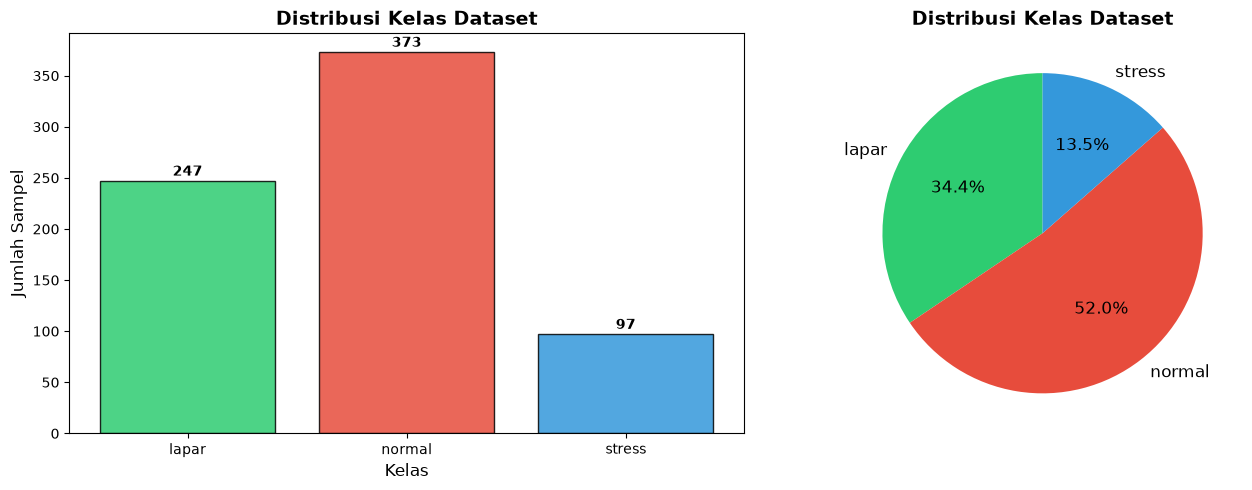

In [ ]:
# Distribusi Kelas
plot_class_distribution(df['label'].values, title='Distribusi Kelas Dataset',
                        save_path=os.path.join(RESULTS_DIR, 'distribusi_kelas.png'))

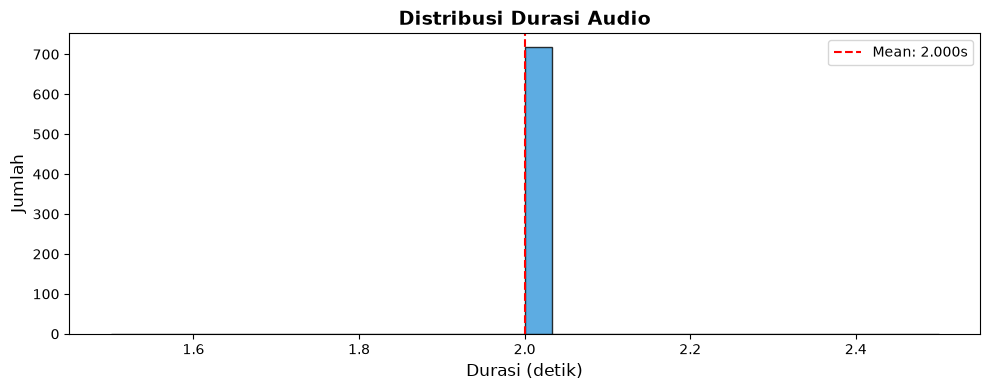

Statistik Durasi:
count    717.0
mean       2.0
std        0.0
min        2.0
25%        2.0
50%        2.0
75%        2.0
max        2.0
Name: duration, dtype: float64


In [ ]:
# Distribusi Durasi Audio
plot_duration_distribution(df['duration'].values)
print('Statistik Durasi:')
print(df['duration'].describe())

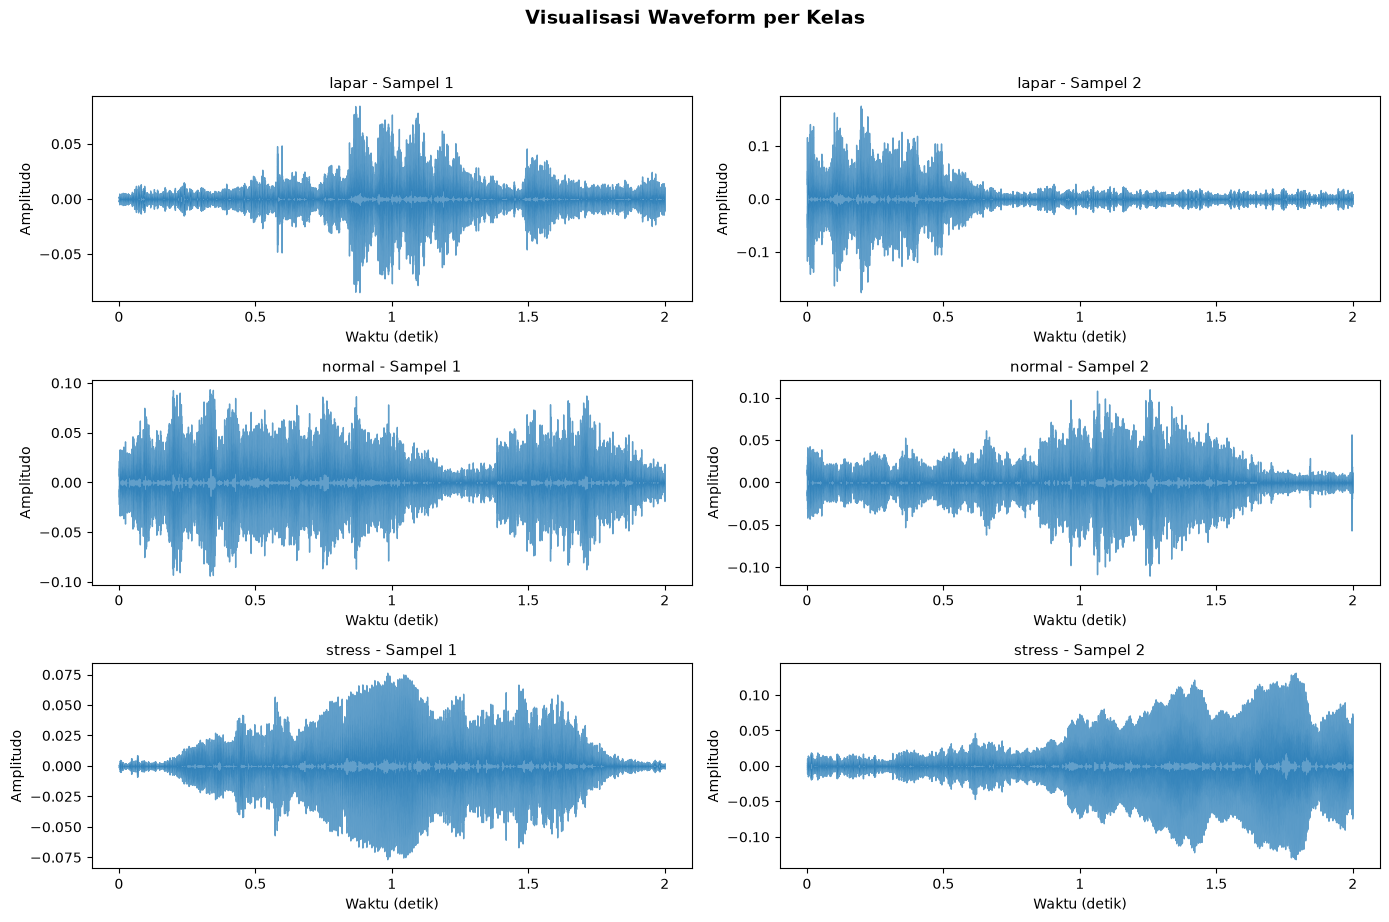

In [ ]:
# Visualisasi Waveform
plot_waveforms(df['signal'].values, df['label'].values, n_samples=2)

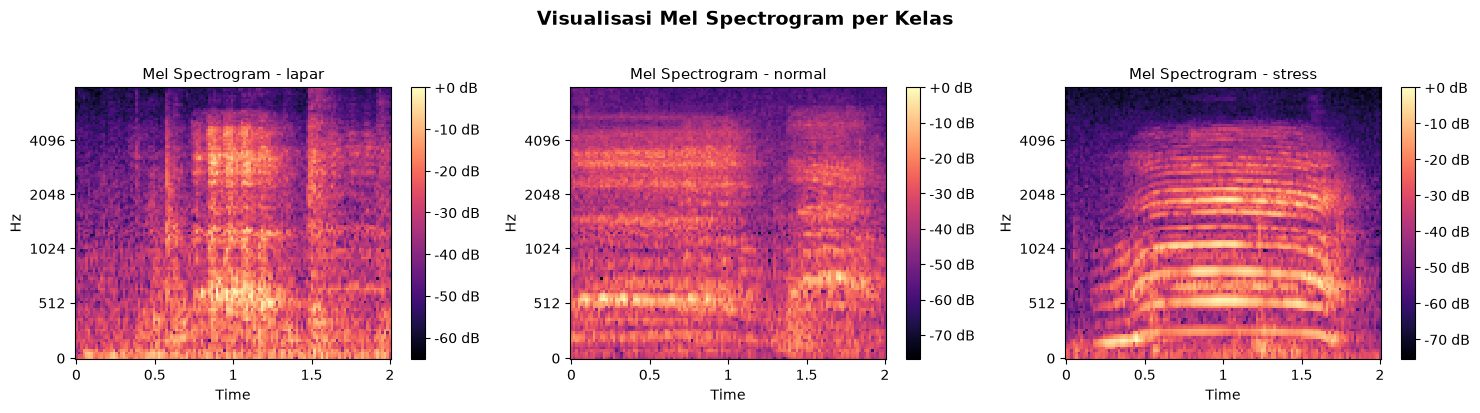

In [ ]:
# Visualisasi Spectrogram
plot_spectrograms(df['signal'].values, df['label'].values)

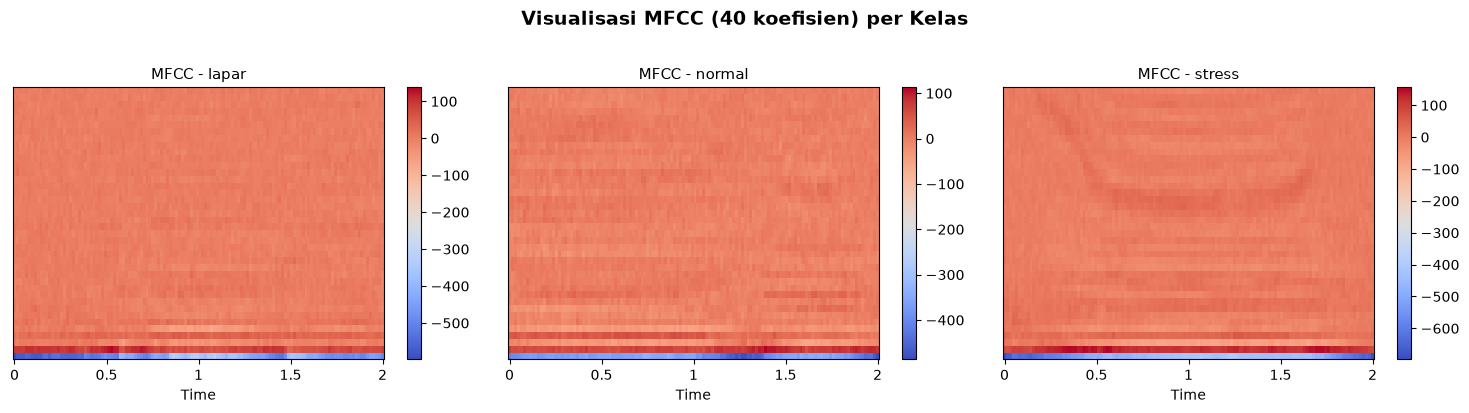

In [ ]:
# Visualisasi MFCC
plot_mfcc_samples(df['signal'].values, df['label'].values, n_mfcc=40)

---
## 5. Train / Validation / Test Split

Pembagian data menggunakan **Stratified Split** dengan rasio:
- **Training**: 70%
- **Validation**: 15%
- **Testing**: 15%

Stratified split memastikan proporsi kelas tetap sama di setiap subset data.

Pembagian Data:
  Training   : 501 sampel
  Validation : 108 sampel
  Testing    : 108 sampel

Distribusi per kelas:
  lapar     : Train=172, Val=37, Test=38
  normal    : Train=261, Val=56, Test=56
  stress    : Train=68, Val=15, Test=14


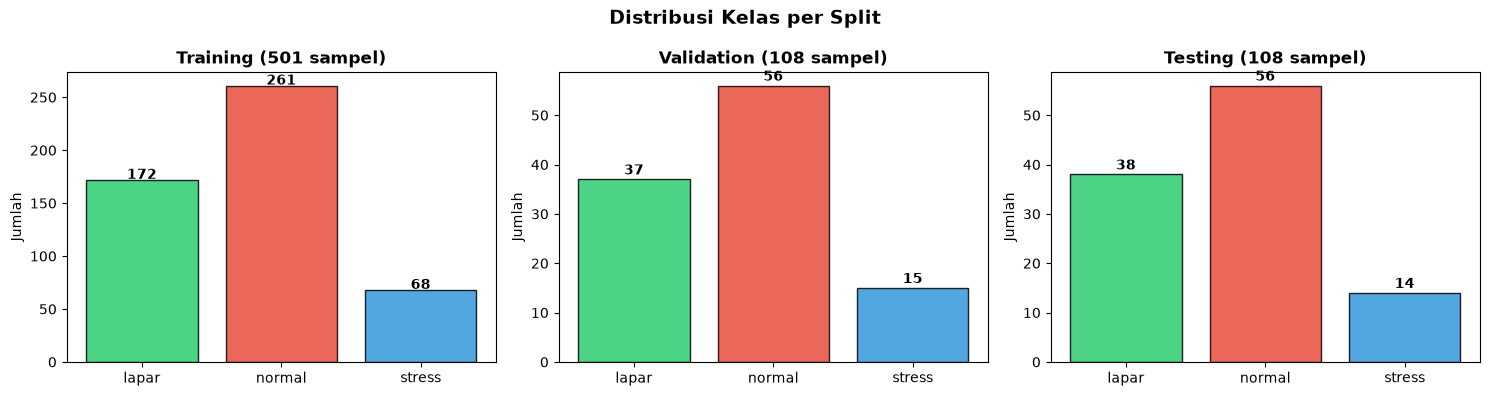

In [51]:
le = LabelEncoder()
le.fit(df['label'].values)

signals_all = df['signal'].tolist()
labels_all = df['label'].tolist()

# Step 1: Split train (70%) dan temp (30%)
train_signals, temp_signals, train_labels, temp_labels = train_test_split(
    signals_all, labels_all, test_size=0.30, stratify=labels_all, random_state=SEED)

# Step 2: Split temp menjadi val (15%) dan test (15%)
val_signals, test_signals, val_labels, test_labels = train_test_split(
    temp_signals, temp_labels, test_size=0.50, stratify=temp_labels, random_state=SEED)

print('Pembagian Data:')
print(f'  Training   : {len(train_labels)} sampel')
print(f'  Validation : {len(val_labels)} sampel')
print(f'  Testing    : {len(test_labels)} sampel')
print('\nDistribusi per kelas:')
for cls in CLASSES:
    tr = sum(1 for l in train_labels if l == cls)
    va = sum(1 for l in val_labels if l == cls)
    te = sum(1 for l in test_labels if l == cls)
    print(f'  {cls:10s}: Train={tr}, Val={va}, Test={te}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, lbls) in zip(axes, [('Training', train_labels),
                                     ('Validation', val_labels),
                                     ('Testing', test_labels)]):
    counts = pd.Series(lbls).value_counts().sort_index()
    ax.bar(counts.index, counts.values, color=['#2ecc71', '#e74c3c', '#3498db'],
           edgecolor='black', alpha=0.85)
    ax.set_title(f'{name} ({len(lbls)} sampel)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Jumlah')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 1, str(v), ha='center', fontweight='bold')
plt.suptitle('Distribusi Kelas per Split', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'distribusi_split.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Eksperimen 1: Penanganan Imbalanced Data & Data Augmentation


| Skenario | Deskripsi |
|----------|-----------|
| Skenario 1 | **Baseline (Raw)**: Tanpa augmentasi & Tanpa Class Weight |
| Skenario 2 | **Class Weight**: Tanpa augmentasi & Menggunakan Class Weight |
| Skenario 3 | **Augmentasi Balance**: Augmentasi hingga setara kelas mayoritas & Class Weight |
| Skenario 4 | **Augmentasi Ekstrim**: Augmentasi hingga 500 sampel per kelas & Class Weight |

**Note**: Model CNN Baseline, MFCC 40 default.

EKSPERIMEN 1 - SKENARIO 1: RAW IMBALANCED (TANPA CLASS WEIGHT)


Extracting test features: 100%|██████████| 108/108 [00:00<00:00, 449.29it/s]


Model: "CNN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 125, 40)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_21 (Conv1D)              │ (None, 125, 32)        │         3,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_29 (Activation)      │ (None, 125, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_20 (MaxPooling1D) │ (None, 62, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_22 (Conv1D)              │ (None, 62, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_30 (Activation)      │ (None, 62, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_21 (MaxPooling1D) │ (None, 31, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_10     │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,435 (56.39 KB)

 Trainable params: 14,435 (56.39 KB)

 Non-trainable params: 0 (0.00 B)


Training exp1_s1_raw...
Epoch 1/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.3992 - loss: 14.4363 - val_accuracy: 0.5278 - val_loss: 2.1341 - learning_rate: 0.0010
Epoch 2/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4411 - loss: 4.7728 - val_accuracy: 0.6759 - val_loss: 1.1695 - learning_rate: 0.0010
Epoch 3/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6467 - loss: 1.8579 - val_accuracy: 0.7222 - val_loss: 1.1495 - learning_rate: 0.0010
Epoch 4/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7844 - loss: 0.7996 - val_accuracy: 0.8333 - val_loss: 0.4482 - learning_rate: 0.0010
Epoch 5/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8663 - loss: 0.4165 - val_accuracy: 0.8796 - val_loss: 0.3309 - learning_rate: 0.0010
Epoch 6/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9122 - loss: 0.2930 - val_accuracy: 0.8611 - val_loss: 0.3370 - learning_rate: 0.0010
Epoch 7/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy

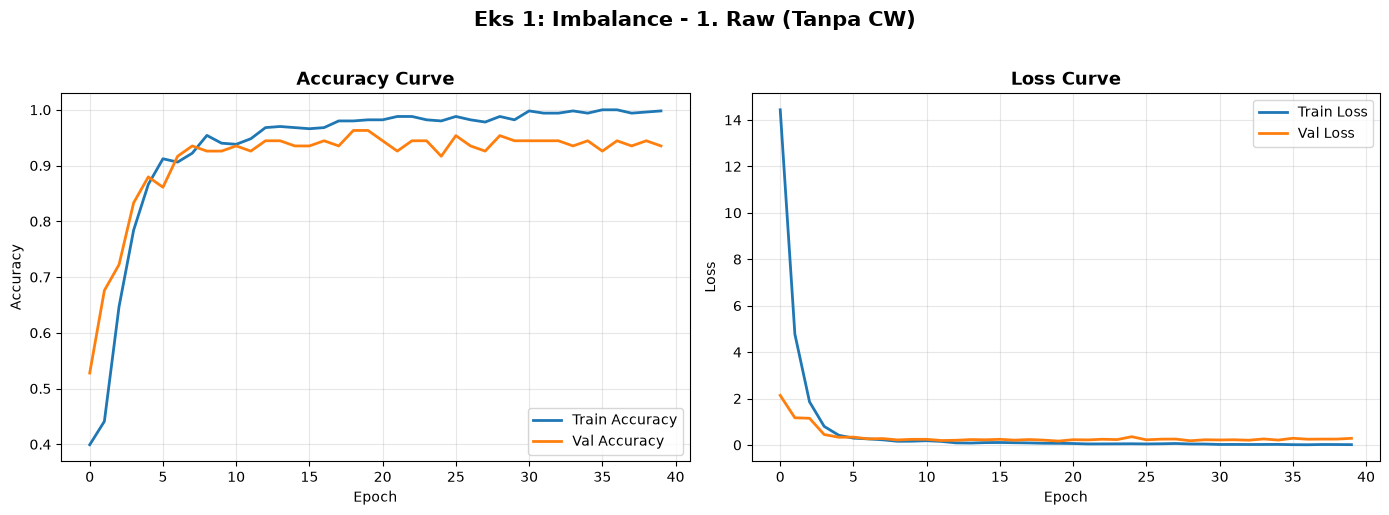


[INFO] File ../Results\exp1_s1_raw_model.keras sudah ada.
[INFO] Model hasil training ini tidak disave agar tidak menabrak file lama.
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step

--- Hasil Evaluasi: Eks 1: Imbalance - 1. Raw (Tanpa CW) ---
Accuracy  : 0.9537
Precision : 0.9553
Recall    : 0.9537
F1 Score  : 0.9534
ROC AUC   : 0.9960

Classification Report:
              precision    recall  f1-score   support

       lapar       0.97      0.95      0.96        38
      normal       0.93      0.98      0.96        56
      stress       1.00      0.86      0.92        14

    accuracy                           0.95       108
   macro avg       0.97      0.93      0.95       108
weighted avg       0.96      0.95      0.95       108



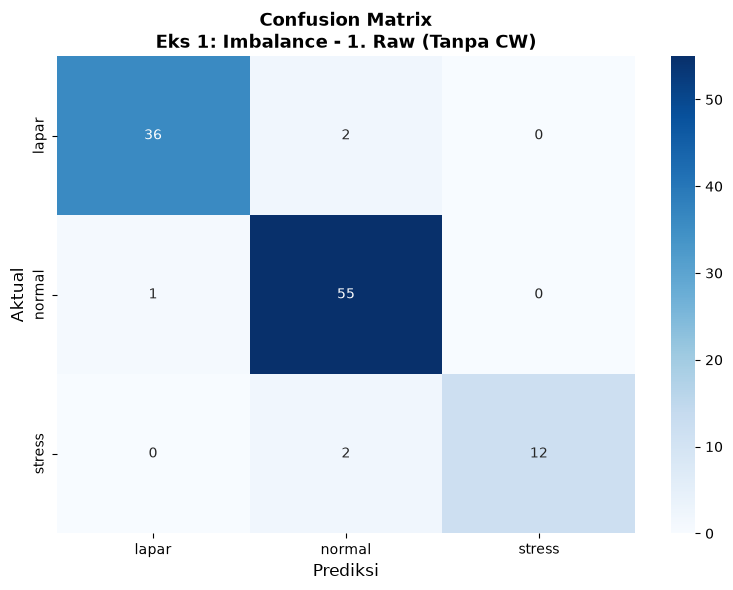

Waktu Eksekusi: 20.13 detik


In [ ]:
print('='*60)
print('EKSPERIMEN 1 - SKENARIO 1: RAW IMBALANCED (TANPA CLASS WEIGHT)')
print('='*60)

result_exp1_s1 = run_experiment(
    train_signals=list(train_signals), train_labels=list(train_labels),
    val_signals=list(val_signals), val_labels=list(val_labels),
    test_signals=list(test_signals), test_labels=list(test_labels),
    le=le, experiment_name='Eks 1: Imbalance', variant_name='1. Raw (Tanpa CW)',
    model_builder='baseline_cnn', feature_method='mfcc', n_mfcc=40,
    use_class_weight=False,
    save_prefix='exp1_s1_raw')

EKSPERIMEN 1 - SKENARIO 2: CLASS WEIGHT (TANPA AUGMENTASI)


Extracting test features: 100%|██████████| 108/108 [00:00<00:00, 194.21it/s]


Model: "CNN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 125, 40)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_23 (Conv1D)              │ (None, 125, 32)        │         3,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_31 (Activation)      │ (None, 125, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_22 (MaxPooling1D) │ (None, 62, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_24 (Conv1D)              │ (None, 62, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_32 (Activation)      │ (None, 62, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_23 (MaxPooling1D) │ (None, 31, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_11     │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,435 (56.39 KB)

 Trainable params: 14,435 (56.39 KB)

 Non-trainable params: 0 (0.00 B)


Training exp1_s2_classweight...
Epoch 1/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.3693 - loss: 14.5967 - val_accuracy: 0.6852 - val_loss: 1.0036 - learning_rate: 0.0010
Epoch 2/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4212 - loss: 5.4671 - val_accuracy: 0.7593 - val_loss: 0.8103 - learning_rate: 0.0010
Epoch 3/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5968 - loss: 2.2600 - val_accuracy: 0.8704 - val_loss: 0.6047 - learning_rate: 0.0010
Epoch 4/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7385 - loss: 1.1520 - val_accuracy: 0.8889 - val_loss: 0.4265 - learning_rate: 0.0010
Epoch 5/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7904 - loss: 0.6317 - val_accuracy: 0.8981 - val_loss: 0.3222 - learning_rate: 0.0010
Epoch 6/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8563 - loss: 0.4441 - val_accuracy: 0.9167 - val_loss: 0.2429 - learning_rate: 0.0010
Epoch 7/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - 

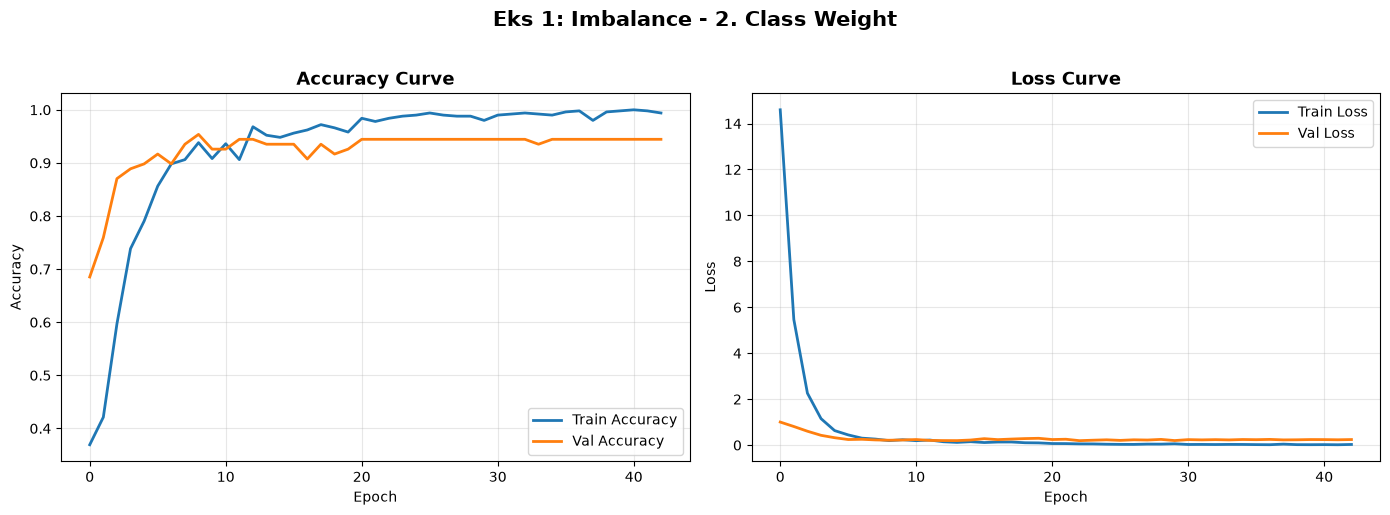


[INFO] File ../Results\exp1_s2_classweight_model.keras sudah ada.
[INFO] Model hasil training ini tidak disave agar tidak menabrak file lama.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

--- Hasil Evaluasi: Eks 1: Imbalance - 2. Class Weight ---
Accuracy  : 0.9537
Precision : 0.9548
Recall    : 0.9537
F1 Score  : 0.9538
ROC AUC   : 0.9961

Classification Report:
              precision    recall  f1-score   support

       lapar       0.93      0.97      0.95        38
      normal       0.96      0.95      0.95        56
      stress       1.00      0.93      0.96        14

    accuracy                           0.95       108
   macro avg       0.96      0.95      0.96       108
weighted avg       0.95      0.95      0.95       108



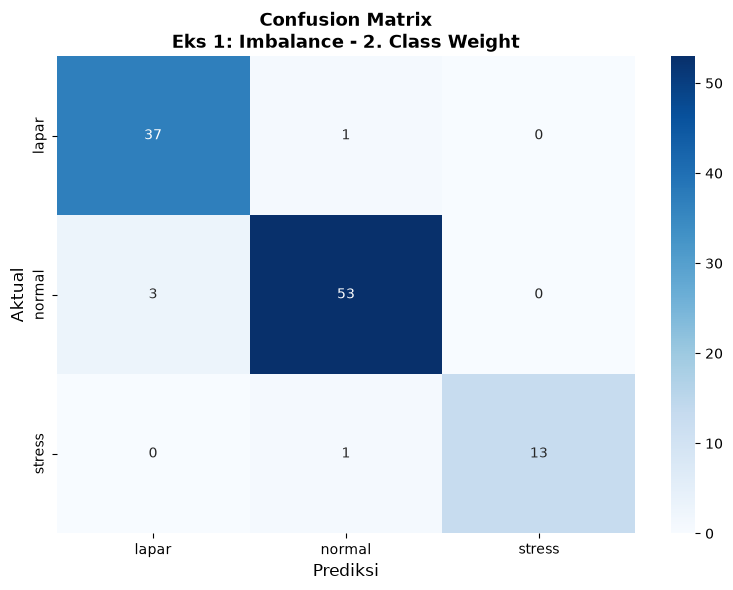

Waktu Eksekusi: 19.10 detik


In [ ]:
print('='*60)
print('EKSPERIMEN 1 - SKENARIO 2: CLASS WEIGHT (TANPA AUGMENTASI)')
print('='*60)

result_exp1_s2 = run_experiment(
    train_signals=list(train_signals), train_labels=list(train_labels),
    val_signals=list(val_signals), val_labels=list(val_labels),
    test_signals=list(test_signals), test_labels=list(test_labels),
    le=le, experiment_name='Eks 1: Imbalance', variant_name='2. Class Weight',
    model_builder='baseline_cnn', feature_method='mfcc', n_mfcc=40,
    use_class_weight=True,
    save_prefix='exp1_s2_classweight')

EKSPERIMEN 1 - SKENARIO 3: AUGMENTASI BALANCE
Target per kelas: 261
  Augmentasi kelas "lapar": 172 -> 261 (+89)
  Augmentasi kelas "stress": 68 -> 261 (+193)

Distribusi training set setelah augmentasi:
  lapar: 261
  normal: 261
  stress: 261


Extracting test features: 100%|██████████| 108/108 [00:00<00:00, 230.40it/s]


Model: "CNN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_14 (InputLayer)     │ (None, 125, 40)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_25 (Conv1D)              │ (None, 125, 32)        │         3,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_33 (Activation)      │ (None, 125, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_24 (MaxPooling1D) │ (None, 62, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_26 (Conv1D)              │ (None, 62, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_34 (Activation)      │ (None, 62, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_25 (MaxPooling1D) │ (None, 31, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_12     │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,435 (56.39 KB)

 Trainable params: 14,435 (56.39 KB)

 Non-trainable params: 0 (0.00 B)


Training exp1_s3_balance...
Epoch 1/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.4010 - loss: 9.7915 - val_accuracy: 0.6019 - val_loss: 1.0001 - learning_rate: 0.0010
Epoch 2/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6003 - loss: 2.0140 - val_accuracy: 0.8426 - val_loss: 0.3761 - learning_rate: 0.0010
Epoch 3/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7688 - loss: 0.6880 - val_accuracy: 0.8611 - val_loss: 0.3262 - learning_rate: 0.0010
Epoch 4/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8710 - loss: 0.3702 - val_accuracy: 0.8981 - val_loss: 0.2764 - learning_rate: 0.0010
Epoch 5/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8914 - loss: 0.2986 - val_accuracy: 0.8889 - val_loss: 0.3162 - learning_rate: 0.0010
Epoch 6/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8966 - loss: 0.2874 - val_accuracy: 0.8981 - val_loss: 0.2805 - learning_rate: 0.0010
Epoch 7/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accurac

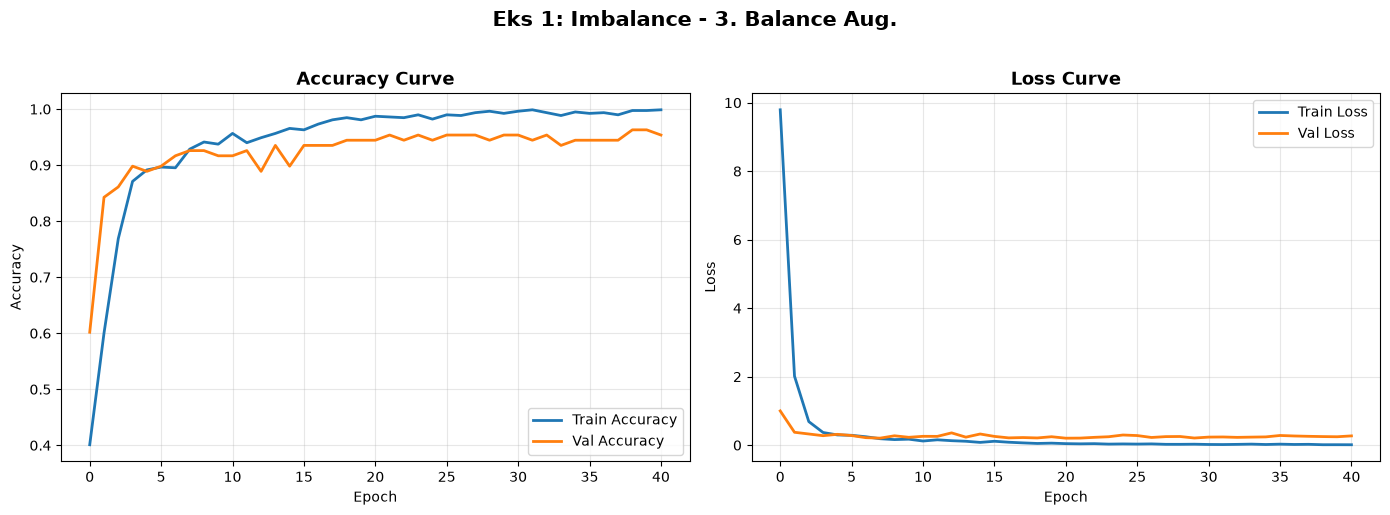


[INFO] File ../Results\exp1_s3_balance_model.keras sudah ada.
[INFO] Model hasil training ini tidak disave agar tidak menabrak file lama.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step

--- Hasil Evaluasi: Eks 1: Imbalance - 3. Balance Aug. ---
Accuracy  : 0.9352
Precision : 0.9361
Recall    : 0.9352
F1 Score  : 0.9355
ROC AUC   : 0.9947

Classification Report:
              precision    recall  f1-score   support

       lapar       0.92      0.92      0.92        38
      normal       0.96      0.95      0.95        56
      stress       0.87      0.93      0.90        14

    accuracy                           0.94       108
   macro avg       0.92      0.93      0.92       108
weighted avg       0.94      0.94      0.94       108



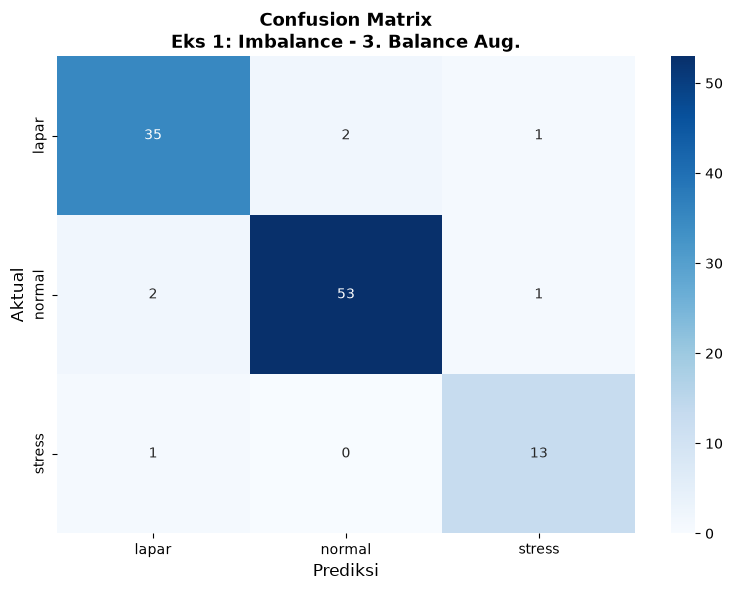

Waktu Eksekusi: 20.87 detik


In [ ]:
print('='*60)
print('EKSPERIMEN 1 - SKENARIO 3: AUGMENTASI BALANCE')
print('='*60)

max_class_count = max(sum(1 for l in train_labels if l == cls) for cls in CLASSES)
print(f'Target per kelas: {max_class_count}')

aug_train_signals_s3, aug_train_labels_s3 = balance_dataset(
    list(train_signals), list(train_labels), target_per_class=max_class_count)

print(f'\nDistribusi training set setelah augmentasi:')
for cls in CLASSES:
    print(f'  {cls}: {sum(1 for l in aug_train_labels_s3 if l == cls)}')

result_exp1_s3 = run_experiment(
    train_signals=aug_train_signals_s3, train_labels=aug_train_labels_s3,
    val_signals=list(val_signals), val_labels=list(val_labels),
    test_signals=list(test_signals), test_labels=list(test_labels),
    le=le, experiment_name='Eks 1: Imbalance', variant_name='3. Balance Aug.',
    model_builder='baseline_cnn', feature_method='mfcc', n_mfcc=40,
    use_class_weight=True,
    save_prefix='exp1_s3_balance')

EKSPERIMEN 1 - SKENARIO 4: AUGMENTASI 500/KELAS
  Augmentasi kelas "lapar": 172 -> 500 (+328)
  Augmentasi kelas "normal": 261 -> 500 (+239)
  Augmentasi kelas "stress": 68 -> 500 (+432)

Distribusi training set setelah augmentasi:
  lapar: 500
  normal: 500
  stress: 500


Extracting test features: 100%|██████████| 108/108 [00:00<00:00, 184.01it/s]


Model: "CNN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_15 (InputLayer)     │ (None, 125, 40)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_27 (Conv1D)              │ (None, 125, 32)        │         3,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_35 (Activation)      │ (None, 125, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_26 (MaxPooling1D) │ (None, 62, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_28 (Conv1D)              │ (None, 62, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_36 (Activation)      │ (None, 62, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_27 (MaxPooling1D) │ (None, 31, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_13     │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,435 (56.39 KB)

 Trainable params: 14,435 (56.39 KB)

 Non-trainable params: 0 (0.00 B)


Training exp1_s4_aug500...
Epoch 1/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.5100 - loss: 6.2739 - val_accuracy: 0.7778 - val_loss: 0.6011 - learning_rate: 0.0010
Epoch 2/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8140 - loss: 0.5059 - val_accuracy: 0.9259 - val_loss: 0.3208 - learning_rate: 0.0010
Epoch 3/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8787 - loss: 0.3308 - val_accuracy: 0.9352 - val_loss: 0.2859 - learning_rate: 0.0010
Epoch 4/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9053 - loss: 0.2412 - val_accuracy: 0.9352 - val_loss: 0.3063 - learning_rate: 0.0010
Epoch 5/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9327 - loss: 0.1813 - val_accuracy: 0.9352 - val_loss: 0.2856 - learning_rate: 0.0010
Epoch 6/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9407 - loss: 0.1596 - val_accuracy: 0.9352 - val_loss: 0.3121 - learning_rate: 0.0010
Epoch 7/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy

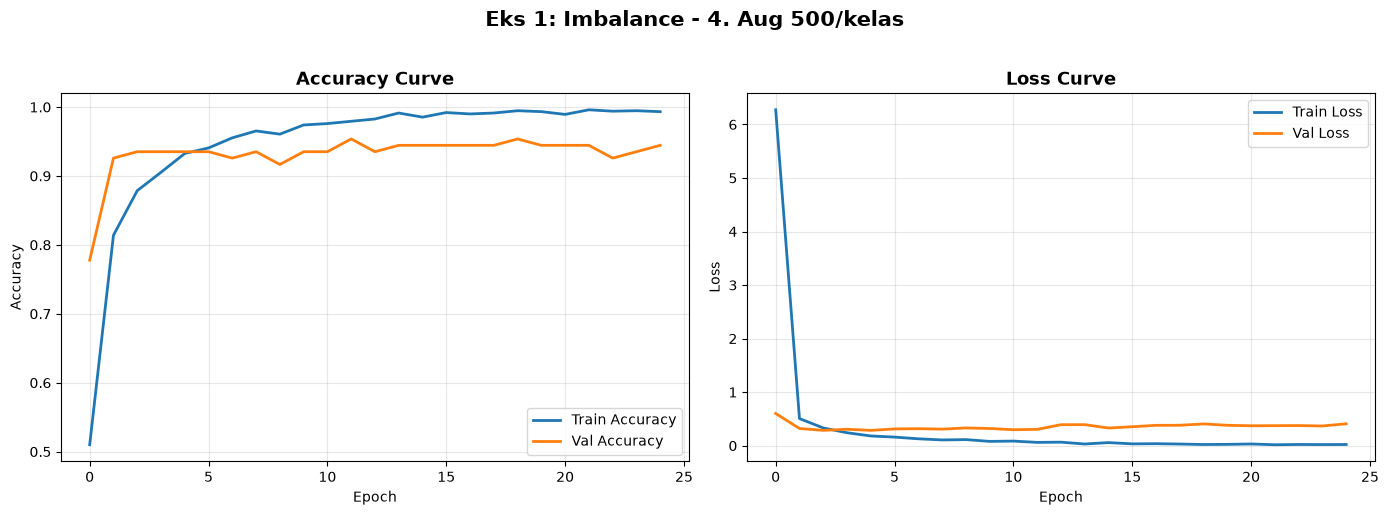


[INFO] File ../Results\exp1_s4_aug500_model.keras sudah ada.
[INFO] Model hasil training ini tidak disave agar tidak menabrak file lama.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

--- Hasil Evaluasi: Eks 1: Imbalance - 4. Aug 500/kelas ---
Accuracy  : 0.9074
Precision : 0.9087
Recall    : 0.9074
F1 Score  : 0.9077
ROC AUC   : 0.9890

Classification Report:
              precision    recall  f1-score   support

       lapar       0.88      0.92      0.90        38
      normal       0.94      0.91      0.93        56
      stress       0.86      0.86      0.86        14

    accuracy                           0.91       108
   macro avg       0.89      0.90      0.89       108
weighted avg       0.91      0.91      0.91       108



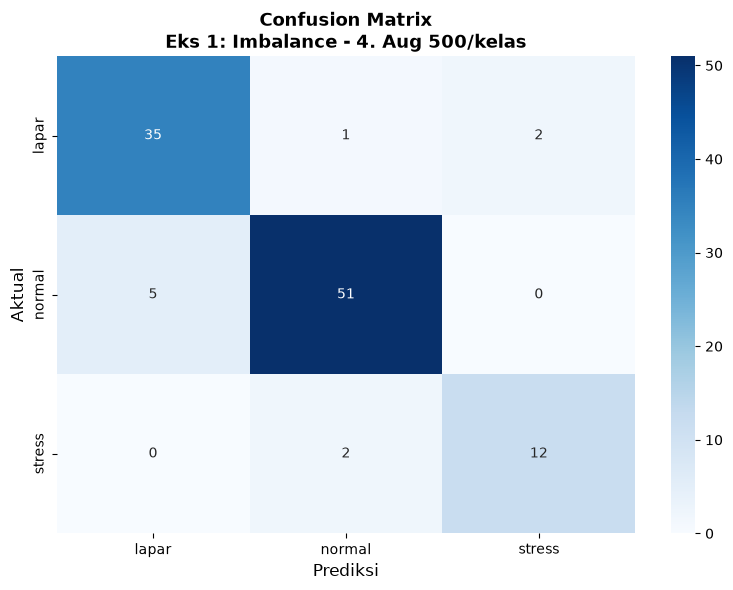

Waktu Eksekusi: 31.67 detik


In [ ]:
print('='*60)
print('EKSPERIMEN 1 - SKENARIO 4: AUGMENTASI 500/KELAS')
print('='*60)

TARGET_500 = 500
aug_train_signals_s4, aug_train_labels_s4 = balance_dataset(
    list(train_signals), list(train_labels), target_per_class=TARGET_500)

print(f'\nDistribusi training set setelah augmentasi:')
for cls in CLASSES:
    print(f'  {cls}: {sum(1 for l in aug_train_labels_s4 if l == cls)}')

result_exp1_s4 = run_experiment(
    train_signals=aug_train_signals_s4, train_labels=aug_train_labels_s4,
    val_signals=list(val_signals), val_labels=list(val_labels),
    test_signals=list(test_signals), test_labels=list(test_labels),
    le=le, experiment_name='Eks 1: Imbalance', variant_name='4. Aug 500/kelas',
    model_builder='baseline_cnn', feature_method='mfcc', n_mfcc=40,
    use_class_weight=True,
    save_prefix='exp1_s4_aug500')

In [ ]:
# Ringkasan Eksperimen 1
print('\n' + '='*60)
print('RINGKASAN EKSPERIMEN 1: PENANGANAN IMBALANCED DATA')
print('='*60)

exp1_results = [result_exp1_s1, result_exp1_s2, result_exp1_s3, result_exp1_s4]
exp1_df = pd.DataFrame(exp1_results)
print(exp1_df.to_string(index=False))

best_exp1_idx = exp1_df['F1'].idxmax()
best_exp1 = exp1_df.iloc[best_exp1_idx]
print(f'\nStrategi terbaik: {best_exp1["Variasi"]} (F1={best_exp1["F1"]:.4f})')

if best_exp1_idx in [0, 1]:
    BEST_AUG_STRATEGY = 'none'
    best_aug_target = None
elif best_exp1_idx == 2:
    BEST_AUG_STRATEGY = 'balance'
    best_aug_target = max_class_count
else:
    BEST_AUG_STRATEGY = 'aug500'
    best_aug_target = TARGET_500
print(f'Strategi Augmentasi yang Diteruskan: {BEST_AUG_STRATEGY}, Target per kelas: {best_aug_target}')


RINGKASAN EKSPERIMEN 1: PENANGANAN IMBALANCED DATA
      Eksperimen           Variasi  Accuracy  Precision  Recall     F1  ROC-AUC  Waktu (detik)
Eks 1: Imbalance 1. Raw (Tanpa CW)    0.9537     0.9553  0.9537 0.9534   0.9960          20.13
Eks 1: Imbalance   2. Class Weight    0.9537     0.9548  0.9537 0.9538   0.9961          19.10
Eks 1: Imbalance   3. Balance Aug.    0.9352     0.9361  0.9352 0.9355   0.9947          20.87
Eks 1: Imbalance  4. Aug 500/kelas    0.9074     0.9087  0.9074 0.9077   0.9890          31.67

✅ Strategi terbaik: 2. Class Weight (F1=0.9538)
   Strategi Augmentasi yang Diteruskan: none, Target per kelas: None


---
## 7. Eksperimen 2: Optimasi Jumlah Koefisien MFCC


| Variasi | Koefisien | 
|---------|-----------|
| MFCC 13 | 13 | 
| MFCC 20 | 20 | 
| MFCC 40 | 40 | 

**Note**: Model CNN baseline, augmentasi terbaik dari Eksperimen 1. Yang berubah **hanya** koefisien MFCC.

In [ ]:
# Persiapan data training dengan augmentasi terbaik
print(f'Menggunakan strategi augmentasi terbaik: {BEST_AUG_STRATEGY}')
if best_aug_target is not None:
    exp2_train_signals, exp2_train_labels = balance_dataset(
        list(train_signals), list(train_labels), target_per_class=best_aug_target)
else:
    exp2_train_signals = list(train_signals)
    exp2_train_labels = list(train_labels)

print(f'\nDistribusi training set untuk Eksperimen 2:')
for cls in CLASSES:
    print(f'  {cls}: {sum(1 for l in exp2_train_labels if l == cls)}')

Menggunakan strategi augmentasi terbaik: none

Distribusi training set untuk Eksperimen 2:
  lapar: 172
  normal: 261
  stress: 68


EKSPERIMEN 2 - MFCC 13


Extracting test features: 100%|██████████| 108/108 [00:00<00:00, 199.97it/s]


Model: "CNN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_16 (InputLayer)     │ (None, 125, 13)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_29 (Conv1D)              │ (None, 125, 32)        │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_37 (Activation)      │ (None, 125, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_28 (MaxPooling1D) │ (None, 62, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_30 (Conv1D)              │ (None, 62, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_38 (Activation)      │ (None, 62, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_29 (MaxPooling1D) │ (None, 31, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_14     │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,843 (46.26 KB)

 Trainable params: 11,843 (46.26 KB)

 Non-trainable params: 0 (0.00 B)


Training exp2_mfcc13...
Epoch 1/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.3313 - loss: 11.0417 - val_accuracy: 0.5556 - val_loss: 3.8497 - learning_rate: 0.0010
Epoch 2/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4731 - loss: 5.2321 - val_accuracy: 0.6852 - val_loss: 1.5372 - learning_rate: 0.0010
Epoch 3/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5529 - loss: 2.2261 - val_accuracy: 0.7407 - val_loss: 0.7605 - learning_rate: 0.0010
Epoch 4/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5928 - loss: 1.2760 - val_accuracy: 0.8333 - val_loss: 0.5320 - learning_rate: 0.0010
Epoch 5/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7086 - loss: 0.8082 - val_accuracy: 0.7778 - val_loss: 0.5520 - learning_rate: 0.0010
Epoch 6/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6727 - loss: 0.7214 - val_accuracy: 0.7500 - val_loss: 0.6088 - learning_rate: 0.0010
Epoch 7/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy

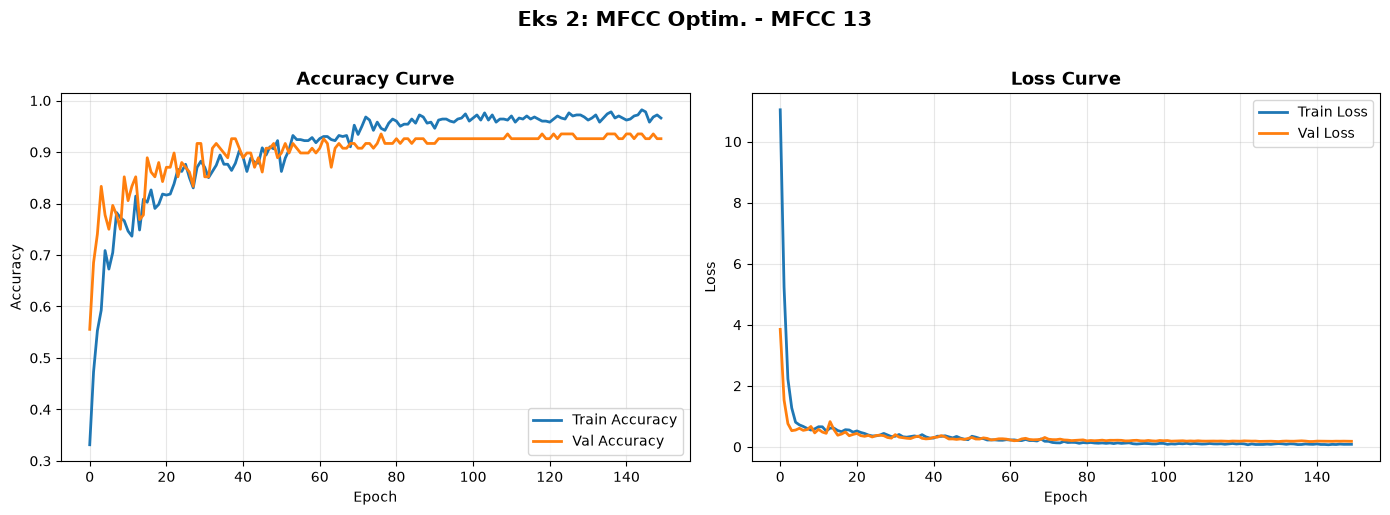


[INFO] File ../Results\exp2_mfcc13_model.keras sudah ada.
[INFO] Model hasil training ini tidak disave agar tidak menabrak file lama.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step

--- Hasil Evaluasi: Eks 2: MFCC Optim. - MFCC 13 ---
Accuracy  : 0.9352
Precision : 0.9350
Recall    : 0.9352
F1 Score  : 0.9341
ROC AUC   : 0.9942

Classification Report:
              precision    recall  f1-score   support

       lapar       0.95      0.92      0.93        38
      normal       0.93      0.98      0.96        56
      stress       0.92      0.79      0.85        14

    accuracy                           0.94       108
   macro avg       0.93      0.90      0.91       108
weighted avg       0.94      0.94      0.93       108



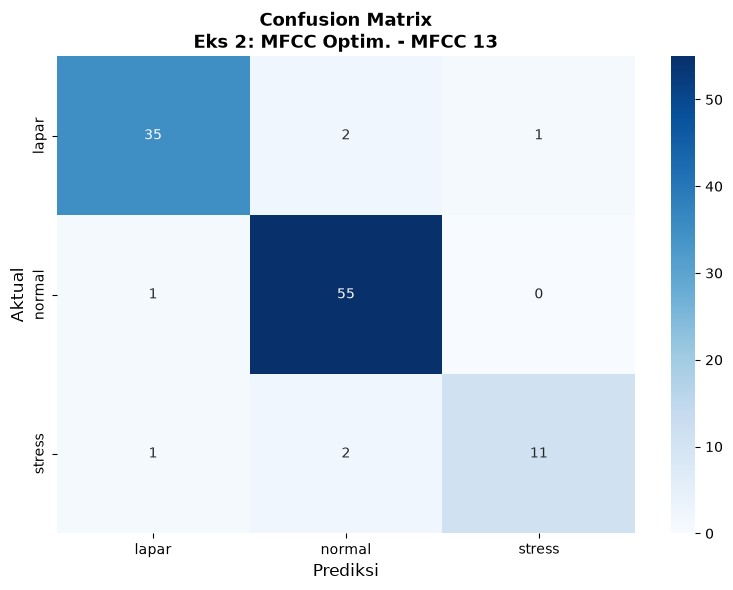

Waktu Eksekusi: 47.95 detik


In [58]:
# ═══ MFCC 13 ═══
print('='*60); print('EKSPERIMEN 2 - MFCC 13'); print('='*60)
result_exp2_m13 = run_experiment(
    train_signals=exp2_train_signals, train_labels=exp2_train_labels,
    val_signals=list(val_signals), val_labels=list(val_labels),
    test_signals=list(test_signals), test_labels=list(test_labels),
    le=le, experiment_name='Eks 2: MFCC Optim.', variant_name='MFCC 13',
    model_builder='baseline_cnn', feature_method='mfcc', n_mfcc=13, save_prefix='exp2_mfcc13')

EKSPERIMEN 2 - MFCC 20


Extracting test features: 100%|██████████| 108/108 [00:00<00:00, 169.30it/s]


Model: "CNN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_17 (InputLayer)     │ (None, 125, 20)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_31 (Conv1D)              │ (None, 125, 32)        │         1,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_39 (Activation)      │ (None, 125, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_30 (MaxPooling1D) │ (None, 62, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_32 (Conv1D)              │ (None, 62, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_40 (Activation)      │ (None, 62, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_31 (MaxPooling1D) │ (None, 31, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_15     │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,515 (48.89 KB)

 Trainable params: 12,515 (48.89 KB)

 Non-trainable params: 0 (0.00 B)


Training exp2_mfcc20...
Epoch 1/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.3533 - loss: 9.1955 - val_accuracy: 0.5278 - val_loss: 2.5551 - learning_rate: 0.0010
Epoch 2/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4571 - loss: 3.3153 - val_accuracy: 0.6481 - val_loss: 1.1692 - learning_rate: 0.0010
Epoch 3/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6527 - loss: 1.4680 - val_accuracy: 0.8519 - val_loss: 0.4189 - learning_rate: 0.0010
Epoch 4/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7305 - loss: 0.6829 - val_accuracy: 0.7685 - val_loss: 0.5233 - learning_rate: 0.0010
Epoch 5/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7565 - loss: 0.6200 - val_accuracy: 0.8426 - val_loss: 0.3672 - learning_rate: 0.0010
Epoch 6/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7964 - loss: 0.5723 - val_accuracy: 0.8333 - val_loss: 0.4243 - learning_rate: 0.0010
Epoch 7/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy:

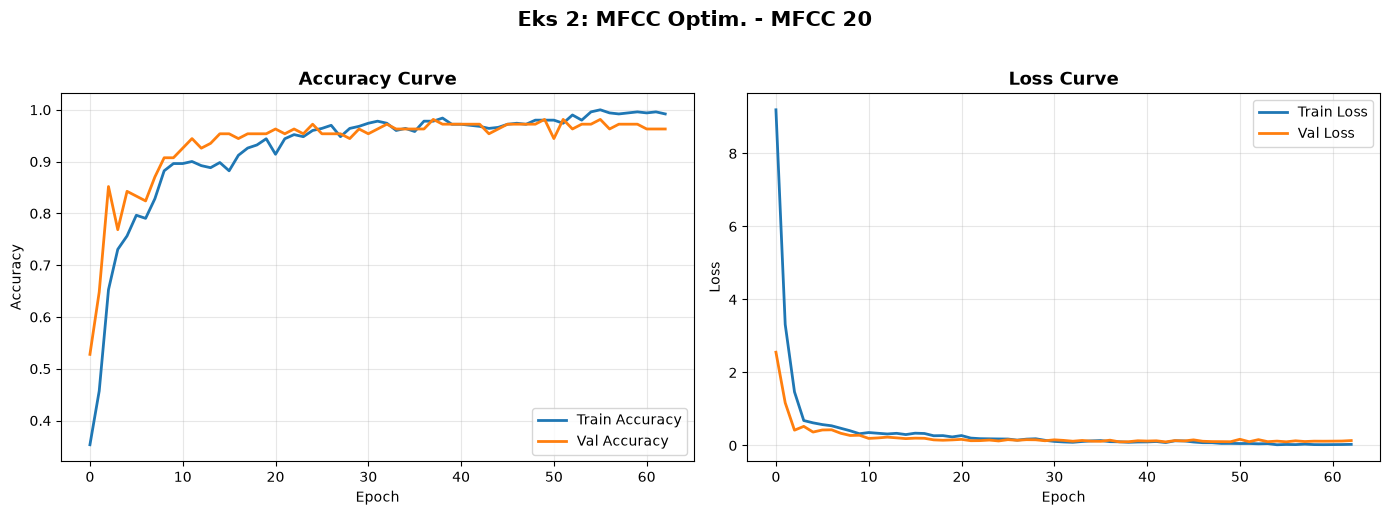


[INFO] File ../Results\exp2_mfcc20_model.keras sudah ada.
[INFO] Model hasil training ini tidak disave agar tidak menabrak file lama.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step

--- Hasil Evaluasi: Eks 2: MFCC Optim. - MFCC 20 ---
Accuracy  : 0.9907
Precision : 0.9910
Recall    : 0.9907
F1 Score  : 0.9908
ROC AUC   : 0.9989

Classification Report:
              precision    recall  f1-score   support

       lapar       0.97      1.00      0.99        38
      normal       1.00      0.98      0.99        56
      stress       1.00      1.00      1.00        14

    accuracy                           0.99       108
   macro avg       0.99      0.99      0.99       108
weighted avg       0.99      0.99      0.99       108



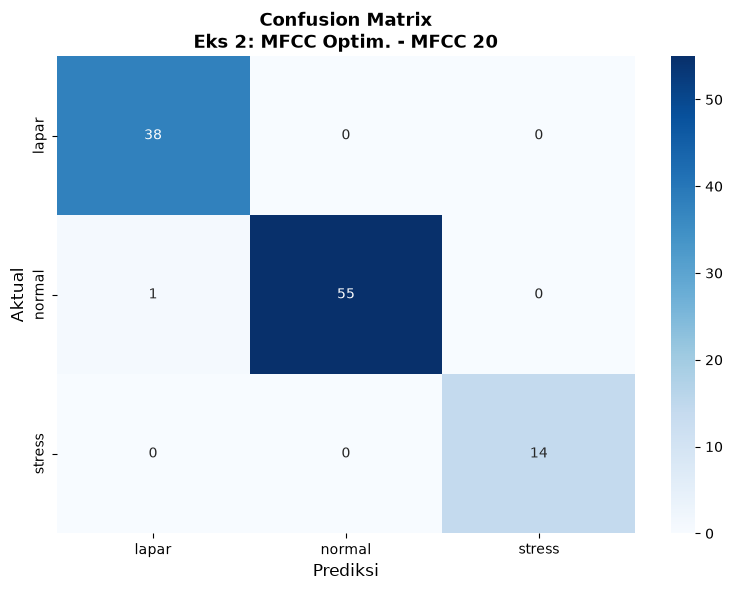

Waktu Eksekusi: 23.76 detik


In [59]:
# ═══ MFCC 20 ═══
print('='*60); print('EKSPERIMEN 2 - MFCC 20'); print('='*60)
result_exp2_m20 = run_experiment(
    train_signals=exp2_train_signals, train_labels=exp2_train_labels,
    val_signals=list(val_signals), val_labels=list(val_labels),
    test_signals=list(test_signals), test_labels=list(test_labels),
    le=le, experiment_name='Eks 2: MFCC Optim.', variant_name='MFCC 20',
    model_builder='baseline_cnn', feature_method='mfcc', n_mfcc=20, save_prefix='exp2_mfcc20')

EKSPERIMEN 2 - MFCC 40 DEFAULT


Extracting test features: 100%|██████████| 108/108 [00:00<00:00, 196.46it/s]


Model: "CNN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_18 (InputLayer)     │ (None, 125, 40)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_33 (Conv1D)              │ (None, 125, 32)        │         3,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_41 (Activation)      │ (None, 125, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_32 (MaxPooling1D) │ (None, 62, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_34 (Conv1D)              │ (None, 62, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_42 (Activation)      │ (None, 62, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_33 (MaxPooling1D) │ (None, 31, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_16     │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,435 (56.39 KB)

 Trainable params: 14,435 (56.39 KB)

 Non-trainable params: 0 (0.00 B)


Training exp2_mfcc40_default...
Epoch 1/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.3693 - loss: 14.5967 - val_accuracy: 0.6852 - val_loss: 1.0036 - learning_rate: 0.0010
Epoch 2/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4212 - loss: 5.4671 - val_accuracy: 0.7593 - val_loss: 0.8103 - learning_rate: 0.0010
Epoch 3/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5968 - loss: 2.2600 - val_accuracy: 0.8704 - val_loss: 0.6047 - learning_rate: 0.0010
Epoch 4/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7385 - loss: 1.1520 - val_accuracy: 0.8889 - val_loss: 0.4265 - learning_rate: 0.0010
Epoch 5/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7904 - loss: 0.6317 - val_accuracy: 0.8981 - val_loss: 0.3222 - learning_rate: 0.0010
Epoch 6/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8563 - loss: 0.4441 - val_accuracy: 0.9167 - val_loss: 0.2429 - learning_rate: 0.0010
Epoch 7/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - a

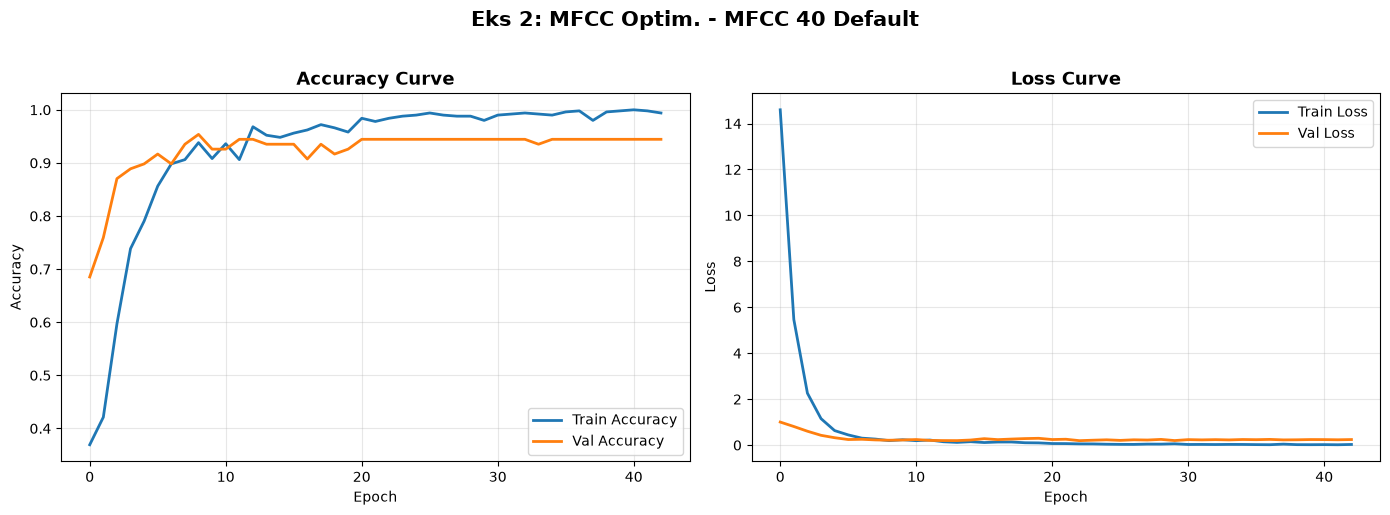


[INFO] File ../Results\exp2_mfcc40_default_model.keras sudah ada.
[INFO] Model hasil training ini tidak disave agar tidak menabrak file lama.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step

--- Hasil Evaluasi: Eks 2: MFCC Optim. - MFCC 40 Default ---
Accuracy  : 0.9537
Precision : 0.9548
Recall    : 0.9537
F1 Score  : 0.9538
ROC AUC   : 0.9961

Classification Report:
              precision    recall  f1-score   support

       lapar       0.93      0.97      0.95        38
      normal       0.96      0.95      0.95        56
      stress       1.00      0.93      0.96        14

    accuracy                           0.95       108
   macro avg       0.96      0.95      0.96       108
weighted avg       0.95      0.95      0.95       108



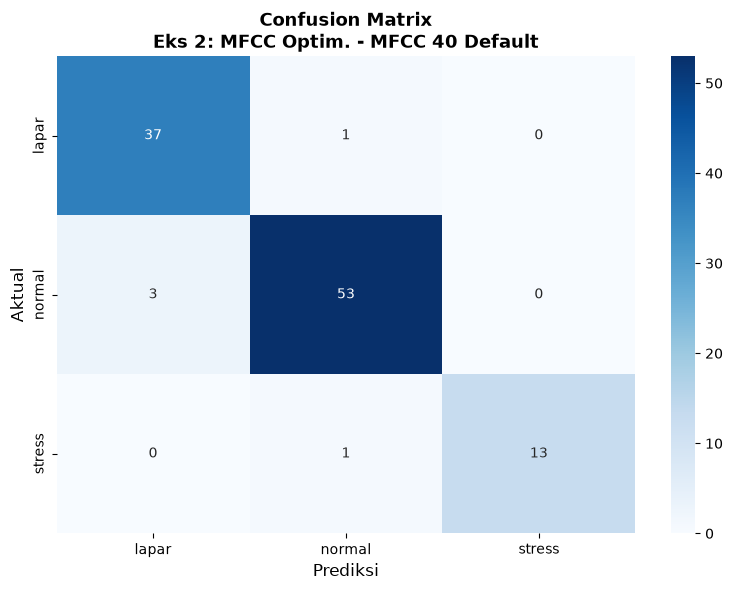

Waktu Eksekusi: 16.08 detik


In [60]:
# ═══ MFCC 40 Default ═══
print('='*60); print('EKSPERIMEN 2 - MFCC 40 DEFAULT'); print('='*60)
result_exp2_m40 = run_experiment(
    train_signals=exp2_train_signals, train_labels=exp2_train_labels,
    val_signals=list(val_signals), val_labels=list(val_labels),
    test_signals=list(test_signals), test_labels=list(test_labels),
    le=le, experiment_name='Eks 2: MFCC Optim.', variant_name='MFCC 40 Default',
    model_builder='baseline_cnn', feature_method='mfcc', n_mfcc=40, save_prefix='exp2_mfcc40_default')

EKSPERIMEN 2 - MFCC 40 IMPROVED
Konfigurasi: Delta + Delta-Delta, StandardScaler, Lifter=22


Extracting test features: 100%|██████████| 108/108 [00:00<00:00, 138.44it/s]


Model: "CNN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_19 (InputLayer)     │ (None, 125, 120)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_35 (Conv1D)              │ (None, 125, 32)        │        11,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_43 (Activation)      │ (None, 125, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_34 (MaxPooling1D) │ (None, 62, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_36 (Conv1D)              │ (None, 62, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_44 (Activation)      │ (None, 62, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_35 (MaxPooling1D) │ (None, 31, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_17     │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,115 (86.39 KB)

 Trainable params: 22,115 (86.39 KB)

 Non-trainable params: 0 (0.00 B)


Training exp2_mfcc40_improved...
Epoch 1/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.3792 - loss: 1.0736 - val_accuracy: 0.8704 - val_loss: 0.8560 - learning_rate: 0.0010
Epoch 2/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7864 - loss: 0.7577 - val_accuracy: 0.8981 - val_loss: 0.5043 - learning_rate: 0.0010
Epoch 3/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9022 - loss: 0.4247 - val_accuracy: 0.9352 - val_loss: 0.2496 - learning_rate: 0.0010
Epoch 4/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9441 - loss: 0.2355 - val_accuracy: 0.9259 - val_loss: 0.1663 - learning_rate: 0.0010
Epoch 5/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9621 - loss: 0.1366 - val_accuracy: 0.9352 - val_loss: 0.1453 - learning_rate: 0.0010
Epoch 6/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9900 - loss: 0.1029 - val_accuracy: 0.9444 - val_loss: 0.1471 - learning_rate: 0.0010
Epoch 7/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - 

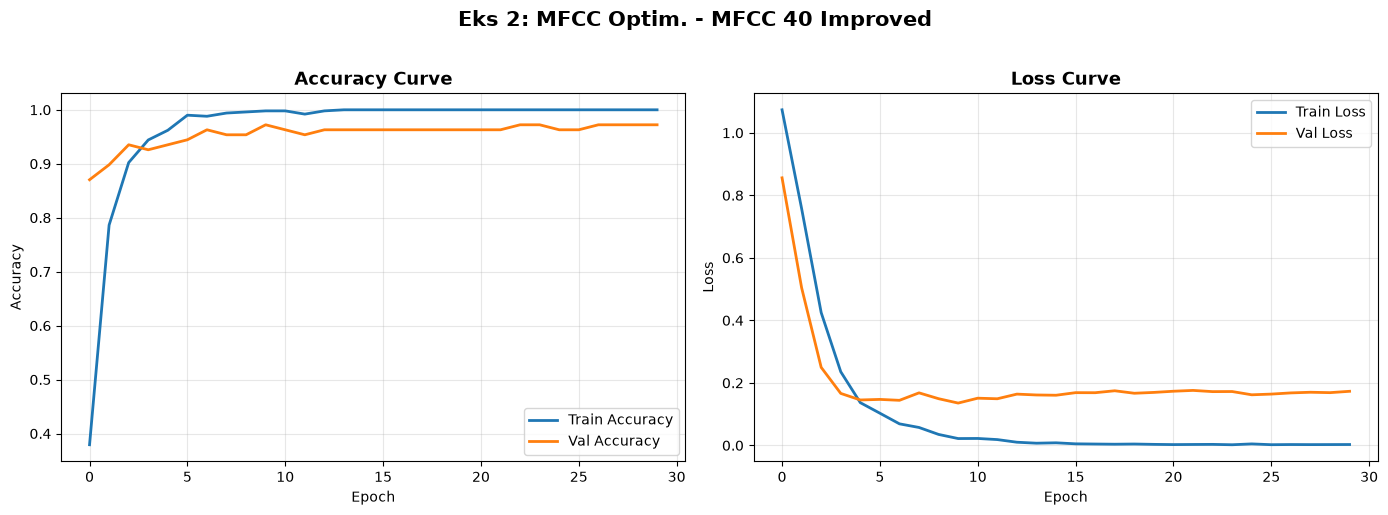


[INFO] File ../Results\exp2_mfcc40_improved_model.keras sudah ada.
[INFO] Model hasil training ini tidak disave agar tidak menabrak file lama.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

--- Hasil Evaluasi: Eks 2: MFCC Optim. - MFCC 40 Improved ---
Accuracy  : 0.9444
Precision : 0.9469
Recall    : 0.9444
F1 Score  : 0.9441
ROC AUC   : 0.9946

Classification Report:
              precision    recall  f1-score   support

       lapar       1.00      0.89      0.94        38
      normal       0.93      1.00      0.97        56
      stress       0.86      0.86      0.86        14

    accuracy                           0.94       108
   macro avg       0.93      0.92      0.92       108
weighted avg       0.95      0.94      0.94       108



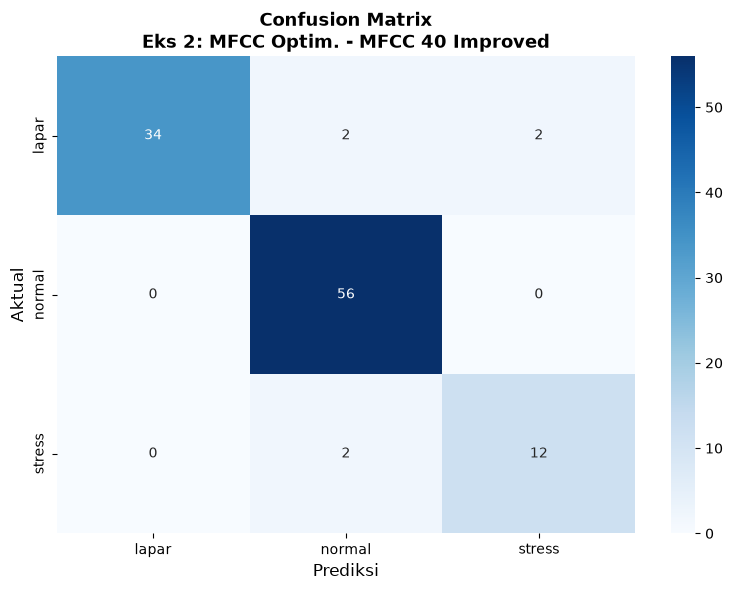

Waktu Eksekusi: 18.44 detik


In [ ]:
# # ═══ MFCC 40 Improved ═══
# print('='*60); print('EKSPERIMEN 2 - MFCC 40 IMPROVED'); print('='*60)
# print('Konfigurasi: Delta + Delta-Delta, StandardScaler, Lifter=22')
# result_exp2_m40i = run_experiment(
#     train_signals=exp2_train_signals, train_labels=exp2_train_labels,
#     val_signals=list(val_signals), val_labels=list(val_labels),
#     test_signals=list(test_signals), test_labels=list(test_labels),
#     le=le, experiment_name='Eks 2: MFCC Optim.', variant_name='MFCC 40 Improved',
#     model_builder='baseline_cnn', feature_method='mfcc', n_mfcc=40,
#     use_delta=True, use_scaler=True, lifter=22, save_prefix='exp2_mfcc40_improved')

In [ ]:
# Ringkasan Eksperimen 2
print('\n' + '='*60)
print('RINGKASAN EKSPERIMEN 2: OPTIMASI KOEFISIEN MFCC')
print('='*60)

exp2_results = [result_exp2_m13, result_exp2_m20, result_exp2_m40]
exp2_df = pd.DataFrame(exp2_results)
print(exp2_df.to_string(index=False))

best_exp2_idx = exp2_df['F1'].idxmax()
best_exp2 = exp2_df.iloc[best_exp2_idx]
print(f'\n✅ MFCC terbaik: {best_exp2["Variasi"]} (F1={best_exp2["F1"]:.4f})')

mfcc_configs = [
    {'n_mfcc': 13, 'use_delta': False, 'use_scaler': False, 'lifter': 0},
    {'n_mfcc': 20, 'use_delta': False, 'use_scaler': False, 'lifter': 0},
    {'n_mfcc': 40, 'use_delta': False, 'use_scaler': False, 'lifter': 0},
]
BEST_MFCC_CONFIG = mfcc_configs[best_exp2_idx]
BEST_MFCC_NAME = best_exp2['Variasi']
print(f'   Konfigurasi MFCC Terbaik yang akan digunakan di Eksperimen 3 & 4: {BEST_MFCC_NAME} -> {BEST_MFCC_CONFIG}')

exp2_df.to_csv(os.path.join(RESULTS_DIR, 'exp2_mfcc_results.csv'), index=False)
print(f'Hasil disimpan: {os.path.join(RESULTS_DIR, "exp2_mfcc_results.csv")}')


RINGKASAN EKSPERIMEN 2: OPTIMASI KOEFISIEN MFCC
        Eksperimen         Variasi  Accuracy  Precision  Recall     F1  ROC-AUC  Waktu (detik)
Eks 2: MFCC Optim.         MFCC 13    0.9352     0.9350  0.9352 0.9341   0.9942          47.95
Eks 2: MFCC Optim.         MFCC 20    0.9907     0.9910  0.9907 0.9908   0.9989          23.76
Eks 2: MFCC Optim. MFCC 40 Default    0.9537     0.9548  0.9537 0.9538   0.9961          16.08

✅ MFCC terbaik: MFCC 20 (F1=0.9908)
   Konfigurasi MFCC Terbaik yang akan digunakan di Eksperimen 3 & 4: MFCC 20 -> {'n_mfcc': 20, 'use_delta': False, 'use_scaler': False, 'lifter': 0}
Hasil disimpan: ../Results\exp2_mfcc_results.csv


---
## 8. Eksperimen 3: Perbandingan MFCC terbaik vs Log-Mel Spectrogram

**Note**: Model CNN sama, augmentasi terbaik. Yang berubah **hanya** metode feature extraction.

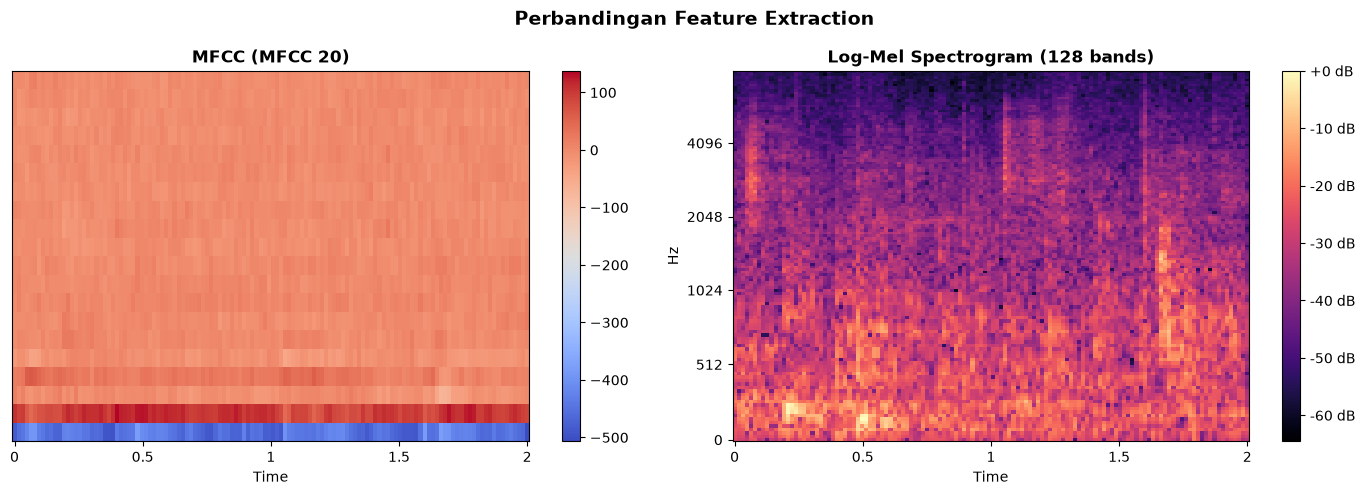

In [ ]:
sample_signal = train_signals[0]
sample_label = train_labels[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mfcc_sample = librosa.feature.mfcc(y=sample_signal, sr=SR,
    n_mfcc=BEST_MFCC_CONFIG['n_mfcc'], n_fft=N_FFT, hop_length=HOP_LENGTH)
img1 = librosa.display.specshow(mfcc_sample, sr=SR, hop_length=HOP_LENGTH,
                                 x_axis='time', ax=axes[0], cmap='coolwarm')
axes[0].set_title(f'MFCC ({BEST_MFCC_NAME})', fontsize=12, fontweight='bold')
fig.colorbar(img1, ax=axes[0])

mel_spec = librosa.feature.melspectrogram(y=sample_signal, sr=SR,
    n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS)
log_mel = librosa.power_to_db(mel_spec, ref=np.max)
img2 = librosa.display.specshow(log_mel, sr=SR, hop_length=HOP_LENGTH,
    x_axis='time', y_axis='mel', ax=axes[1], cmap='magma')
axes[1].set_title(f'Log-Mel Spectrogram ({N_MELS} bands)', fontsize=12, fontweight='bold')
fig.colorbar(img2, ax=axes[1], format='%+2.0f dB')

plt.suptitle('Perbandingan Feature Extraction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'exp3_feature_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

In [64]:
# ═══ MFCC Terbaik ═══
print('='*60); print(f'EKSPERIMEN 3 - {BEST_MFCC_NAME}'); print('='*60)
print('[INFO] Tidak melakukan training ulang untuk MFCC pada Eksperimen 3.')
print('[INFO] Menyalin hasil evaluasi langsung dari Eksperimen 2 untuk perbandingan yang fair dan mencegah randomness.')

# Ambil hasil dari eksperimen 2
result_exp3_mfcc = best_exp2.to_dict()
result_exp3_mfcc['Eksperimen'] = 'Eks 3: Feature Extr.'
if 'Waktu (detik)' not in result_exp3_mfcc:
    result_exp3_mfcc['Waktu (detik)'] = 0.0
all_experiment_results.append(result_exp3_mfcc)

print(f'\nHasil evaluasi {BEST_MFCC_NAME} (Disalin dari Eksperimen 2):')
print(f"Accuracy  : {result_exp3_mfcc['Accuracy']:.4f}")
print(f"F1 Score  : {result_exp3_mfcc['F1']:.4f}")

EKSPERIMEN 3 - MFCC 20
[INFO] Tidak melakukan training ulang untuk MFCC pada Eksperimen 3.
[INFO] Menyalin hasil evaluasi langsung dari Eksperimen 2 untuk perbandingan yang fair dan mencegah randomness.

Hasil evaluasi MFCC 20 (Disalin dari Eksperimen 2):
Accuracy  : 0.9907
F1 Score  : 0.9908


EKSPERIMEN 3 - LOG-MEL SPECTROGRAM


Extracting test features: 100%|██████████| 108/108 [00:00<00:00, 187.67it/s]


Model: "CNN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_20 (InputLayer)     │ (None, 125, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_37 (Conv1D)              │ (None, 125, 32)        │        12,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_45 (Activation)      │ (None, 125, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_36 (MaxPooling1D) │ (None, 62, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_38 (Conv1D)              │ (None, 62, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_46 (Activation)      │ (None, 62, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_37 (MaxPooling1D) │ (None, 31, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_18     │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,883 (89.39 KB)

 Trainable params: 22,883 (89.39 KB)

 Non-trainable params: 0 (0.00 B)


Training exp3_logmel...
Epoch 1/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.2774 - loss: 12.3379 - val_accuracy: 0.5185 - val_loss: 2.1218 - learning_rate: 0.0010
Epoch 2/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3653 - loss: 2.1298 - val_accuracy: 0.4537 - val_loss: 1.0825 - learning_rate: 0.0010
Epoch 3/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2974 - loss: 1.0832 - val_accuracy: 0.2778 - val_loss: 1.0953 - learning_rate: 0.0010
Epoch 4/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.2335 - loss: 1.0285 - val_accuracy: 0.3426 - val_loss: 1.0732 - learning_rate: 0.0010
Epoch 5/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3353 - loss: 1.0189 - val_accuracy: 0.3981 - val_loss: 1.0646 - learning_rate: 0.0010
Epoch 6/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3553 - loss: 1.0268 - val_accuracy: 0.4444 - val_loss: 1.0802 - learning_rate: 0.0010
Epoch 7/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy

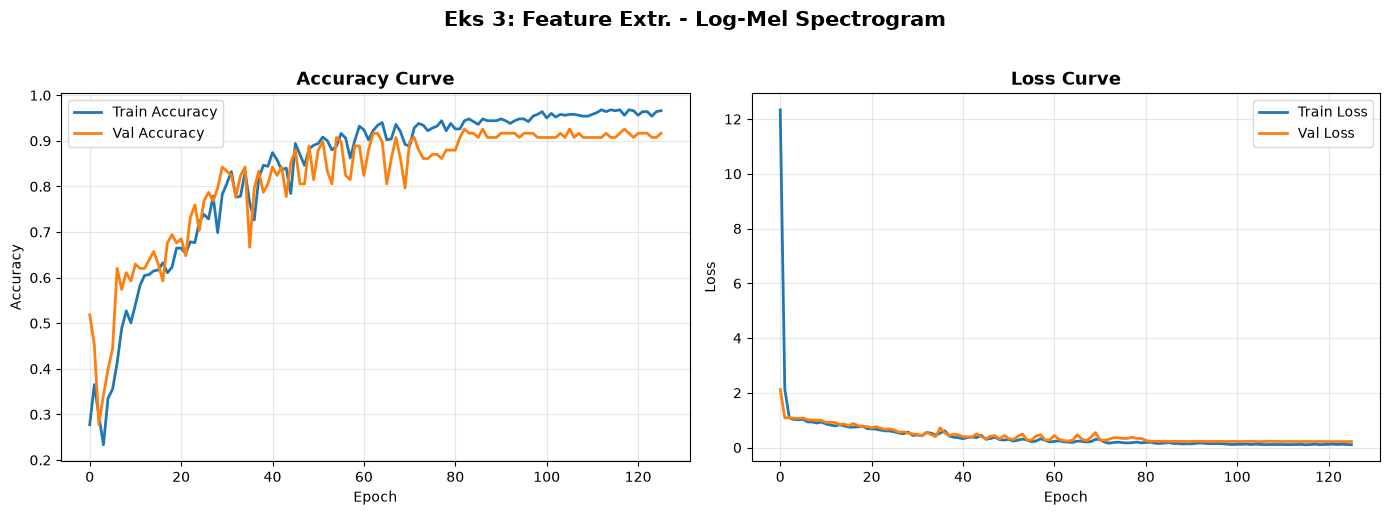


[INFO] File ../Results\exp3_logmel_model.keras sudah ada.
[INFO] Model hasil training ini tidak disave agar tidak menabrak file lama.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step

--- Hasil Evaluasi: Eks 3: Feature Extr. - Log-Mel Spectrogram ---
Accuracy  : 0.9167
Precision : 0.9167
Recall    : 0.9167
F1 Score  : 0.9167
ROC AUC   : 0.9754

Classification Report:
              precision    recall  f1-score   support

       lapar       0.89      0.89      0.89        38
      normal       0.93      0.93      0.93        56
      stress       0.93      0.93      0.93        14

    accuracy                           0.92       108
   macro avg       0.92      0.92      0.92       108
weighted avg       0.92      0.92      0.92       108



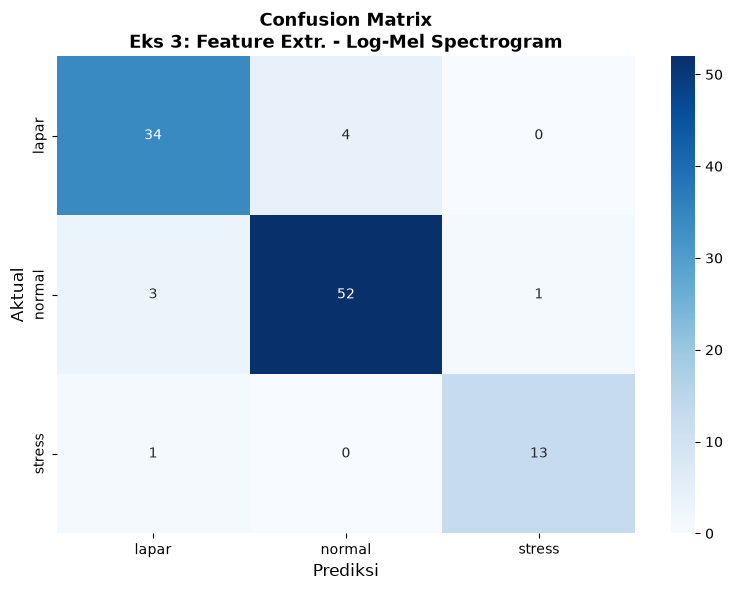

Waktu Eksekusi: 49.49 detik


In [65]:
# ═══ Log-Mel Spectrogram ═══
print('='*60); print('EKSPERIMEN 3 - LOG-MEL SPECTROGRAM'); print('='*60)
result_exp3_logmel = run_experiment(
    train_signals=exp2_train_signals, train_labels=exp2_train_labels,
    val_signals=list(val_signals), val_labels=list(val_labels),
    test_signals=list(test_signals), test_labels=list(test_labels),
    le=le, experiment_name='Eks 3: Feature Extr.', variant_name='Log-Mel Spectrogram',
    model_builder='baseline_cnn', feature_method='logmel', save_prefix='exp3_logmel')

In [ ]:
# Ringkasan Eksperimen 3
print('\n' + '='*60)
print('RINGKASAN EKSPERIMEN 3: PERBANDINGAN FEATURE EXTRACTION')
print('='*60)

exp3_results = [result_exp3_mfcc, result_exp3_logmel]
exp3_df = pd.DataFrame(exp3_results)
print(exp3_df.to_string(index=False))

best_exp3_idx = exp3_df['F1'].idxmax()
best_exp3 = exp3_df.iloc[best_exp3_idx]
print(f'\n✅ Feature terbaik: {best_exp3["Variasi"]} (F1={best_exp3["F1"]:.4f})')

if best_exp3_idx == 0:
    BEST_FEATURE_METHOD = 'mfcc'
    BEST_FEATURE_NAME = BEST_MFCC_NAME
    BEST_FEATURE_KWARGS = BEST_MFCC_CONFIG.copy()
else:
    BEST_FEATURE_METHOD = 'logmel'
    BEST_FEATURE_NAME = 'Log-Mel Spectrogram'
    BEST_FEATURE_KWARGS = {}
print(f'   Metode: {BEST_FEATURE_METHOD}')


RINGKASAN EKSPERIMEN 3: PERBANDINGAN FEATURE EXTRACTION
          Eksperimen             Variasi  Accuracy  Precision  Recall     F1  ROC-AUC  Waktu (detik)
Eks 3: Feature Extr.             MFCC 20    0.9907     0.9910  0.9907 0.9908   0.9989          23.76
Eks 3: Feature Extr. Log-Mel Spectrogram    0.9167     0.9167  0.9167 0.9167   0.9754          49.49

✅ Feature terbaik: MFCC 20 (F1=0.9908)
   Metode: mfcc


---
## 9. Eksperimen 4: Perbandingan Model Deep Learning


| Model | Arsitektur |
|-------|-----------|
| DNN | Dense(512)→Dense(256)→Dense(128)→Dense(64)→Output |
| CNN Baseline | Conv1D(32→64) + GAP → Dense(64) + Dropout(0.3) → Output |
| CNN Improved | Conv1D(64→128→256) + BN + SpatialDropout + L2 + GAP→Dense(256→64)→Output |
| LSTM | BiLSTM(128)→BiLSTM(64)→BiLSTM(32)→Dense(128)→Dense(64)→Output |

In [ ]:
# Gunakan MFCC Terbaik dari Eksperimen 2
BEST_FEATURE_METHOD = 'mfcc'
BEST_FEATURE_KWARGS = BEST_MFCC_CONFIG.copy()

print(f'Fitur yang digunakan untuk Eksperimen 4: {BEST_MFCC_NAME}')
print(f'Konfigurasi: {BEST_FEATURE_KWARGS}')

Fitur yang digunakan untuk Eksperimen 4: MFCC 20
Konfigurasi: {'n_mfcc': 20, 'use_delta': False, 'use_scaler': False, 'lifter': 0}


EKSPERIMEN 4 - DNN


Extracting test features: 100%|██████████| 108/108 [00:00<00:00, 193.09it/s]


Model: "DNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_47 (Dense)                │ (None, 512)            │     1,280,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_47 (Activation)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_48 (Activation)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_49 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_50 (Activation)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,457,027 (5.56 MB)

 Trainable params: 1,455,107 (5.55 MB)

 Non-trainable params: 1,920 (7.50 KB)


Training exp4_dnn_mfcc_20...
Epoch 1/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - accuracy: 0.4790 - loss: 1.1712 - val_accuracy: 0.1389 - val_loss: 12.9453 - learning_rate: 0.0010
Epoch 2/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6886 - loss: 0.7978 - val_accuracy: 0.1389 - val_loss: 20.7275 - learning_rate: 0.0010
Epoch 3/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8263 - loss: 0.6038 - val_accuracy: 0.1389 - val_loss: 16.7695 - learning_rate: 0.0010
Epoch 4/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8842 - loss: 0.4821 - val_accuracy: 0.1389 - val_loss: 18.3637 - learning_rate: 0.0010
Epoch 5/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9082 - loss: 0.4237 - val_accuracy: 0.1389 - val_loss: 17.0965 - learning_rate: 0.0010
Epoch 6/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9361 - loss: 0.3760 - val_accuracy: 0.1389 - val_loss: 13.5069 - learning_rate: 0.0010
Epoch 7/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step 

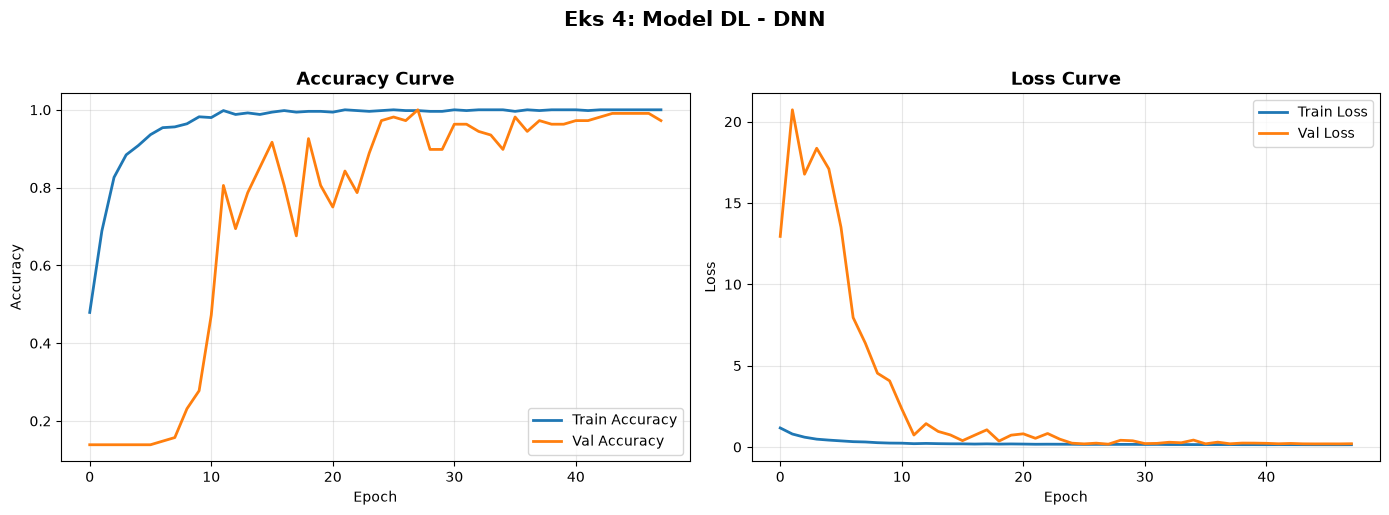

Model disimpan: ../Results\exp4_dnn_mfcc_20_model.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step

--- Hasil Evaluasi: Eks 4: Model DL - DNN ---
Accuracy  : 0.9352
Precision : 0.9419
Recall    : 0.9352
F1 Score  : 0.9356
ROC AUC   : 0.9914

Classification Report:
              precision    recall  f1-score   support

       lapar       0.88      0.97      0.93        38
      normal       1.00      0.89      0.94        56
      stress       0.88      1.00      0.93        14

    accuracy                           0.94       108
   macro avg       0.92      0.96      0.93       108
weighted avg       0.94      0.94      0.94       108



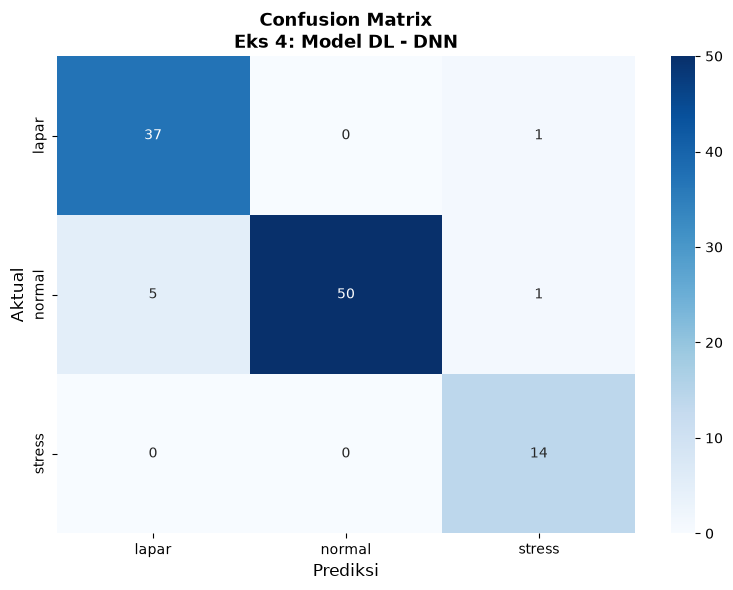

Waktu Eksekusi: 33.18 detik


In [68]:
# ═══ DNN ═══
print('='*60); print('EKSPERIMEN 4 - DNN'); print('='*60)
result_exp4_dnn = run_experiment(
    train_signals=exp2_train_signals, train_labels=exp2_train_labels,
    val_signals=list(val_signals), val_labels=list(val_labels),
    test_signals=list(test_signals), test_labels=list(test_labels),
    le=le, experiment_name='Eks 4: Model DL', variant_name='DNN',
    model_builder='dnn', feature_method=BEST_FEATURE_METHOD,
    **BEST_FEATURE_KWARGS, save_prefix=f'exp4_dnn_{BEST_MFCC_NAME.lower().replace(" ", "_")}')

EKSPERIMEN 4 - CNN


Extracting test features: 100%|██████████| 108/108 [00:00<00:00, 236.55it/s]


Model: "CNN_Advanced"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_22 (InputLayer)     │ (None, 125, 20)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_39 (Conv1D)              │ (None, 125, 64)        │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 125, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_51 (Activation)      │ (None, 125, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_38 (MaxPooling1D) │ (None, 62, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ (None, 62, 64)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_40 (Conv1D)              │ (None, 62, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 62, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_52 (Activation)      │ (None, 62, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_39 (MaxPooling1D) │ (None, 31, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_3             │ (None, 31, 128)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_41 (Conv1D)              │ (None, 31, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 31, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_53 (Activation)      │ (None, 31, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_19     │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_54 (Activation)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │             

 Total params: 215,235 (840.76 KB)

 Trainable params: 213,699 (834.76 KB)

 Non-trainable params: 1,536 (6.00 KB)


Training exp4_cnn_mfcc_20...
Epoch 1/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - accuracy: 0.5768 - loss: 0.9436 - val_accuracy: 0.1389 - val_loss: 16.9430 - learning_rate: 0.0010
Epoch 2/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8184 - loss: 0.4972 - val_accuracy: 0.1389 - val_loss: 13.8187 - learning_rate: 0.0010
Epoch 3/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.8862 - loss: 0.3988 - val_accuracy: 0.1389 - val_loss: 13.0519 - learning_rate: 0.0010
Epoch 4/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.9202 - loss: 0.3039 - val_accuracy: 0.1389 - val_loss: 11.3935 - learning_rate: 0.0010
Epoch 5/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9082 - loss: 0.3029 - val_accuracy: 0.1389 - val_loss: 10.5048 - learning_rate: 0.0010
Epoch 6/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9281 - loss: 0.2752 - val_accuracy: 0.1389 - val_loss: 9.4886 - learning_rate: 0.0010
Epoch 7/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step 

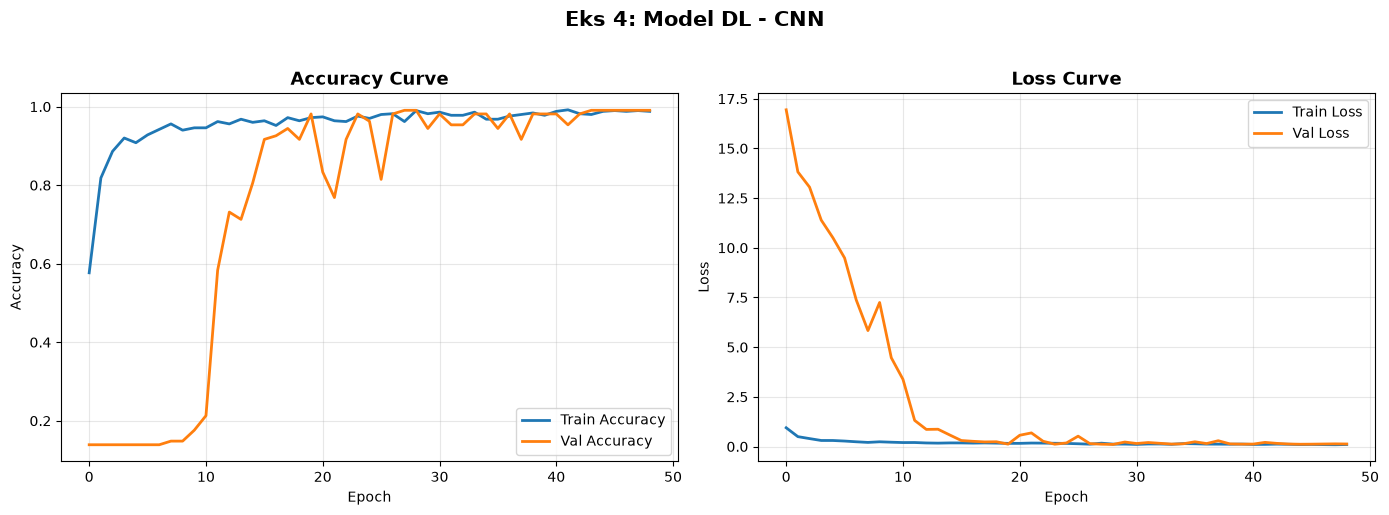

Model disimpan: ../Results\exp4_cnn_mfcc_20_model.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step

--- Hasil Evaluasi: Eks 4: Model DL - CNN ---
Accuracy  : 0.9352
Precision : 0.9423
Recall    : 0.9352
F1 Score  : 0.9358
ROC AUC   : 0.9970

Classification Report:
              precision    recall  f1-score   support

       lapar       0.86      0.97      0.91        38
      normal       1.00      0.89      0.94        56
      stress       0.93      1.00      0.97        14

    accuracy                           0.94       108
   macro avg       0.93      0.96      0.94       108
weighted avg       0.94      0.94      0.94       108



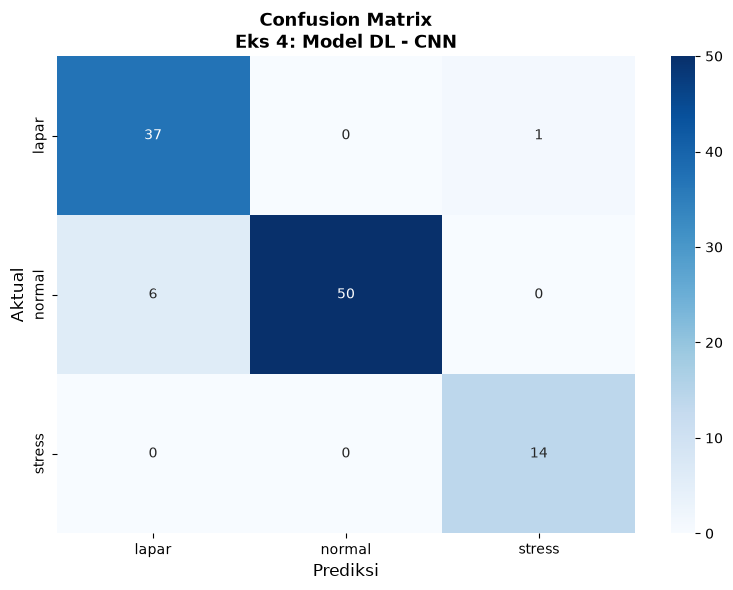

Waktu Eksekusi: 43.48 detik


In [69]:
# ═══ CNN ═══
print('='*60); print('EKSPERIMEN 4 - CNN'); print('='*60)
result_exp4_cnn = run_experiment(
    train_signals=exp2_train_signals, train_labels=exp2_train_labels,
    val_signals=list(val_signals), val_labels=list(val_labels),
    test_signals=list(test_signals), test_labels=list(test_labels),
    le=le, experiment_name='Eks 4: Model DL', variant_name='CNN',
    model_builder='advanced_cnn', feature_method=BEST_FEATURE_METHOD,
    **BEST_FEATURE_KWARGS, save_prefix=f'exp4_cnn_{BEST_MFCC_NAME.lower().replace(" ", "_")}')

EKSPERIMEN 4 - LSTM


Extracting test features: 100%|██████████| 108/108 [00:00<00:00, 171.75it/s]


Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_23 (InputLayer)     │ (None, 125, 20)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 125, 256)       │       152,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 125, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 125, 128)       │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 125, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_56 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_57 (Activation)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 377,475 (1.44 MB)

 Trainable params: 376,195 (1.44 MB)

 Non-trainable params: 1,280 (5.00 KB)


Training exp4_lstm_mfcc_20...
Epoch 1/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 33s 773ms/step - accuracy: 0.3593 - loss: 1.5624 - val_accuracy: 0.5370 - val_loss: 1.1438 - learning_rate: 0.0010
Epoch 2/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 572ms/step - accuracy: 0.3333 - loss: 1.4761 - val_accuracy: 0.5648 - val_loss: 1.1358 - learning_rate: 0.0010
Epoch 3/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 571ms/step - accuracy: 0.3313 - loss: 1.4299 - val_accuracy: 0.5926 - val_loss: 1.1403 - learning_rate: 0.0010
Epoch 4/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 714ms/step - accuracy: 0.3573 - loss: 1.4178 - val_accuracy: 0.5926 - val_loss: 1.1611 - learning_rate: 0.0010
Epoch 5/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 599ms/step - accuracy: 0.3353 - loss: 1.4035 - val_accuracy: 0.6019 - val_loss: 1.1624 - learning_rate: 0.0010
Epoch 6/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 517ms/step - accuracy: 0.3673 - loss: 1.3330 - val_accuracy: 0.5833 - val_loss: 1.1535 - learning_rate: 0.0010
Epoch 7/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 588ms

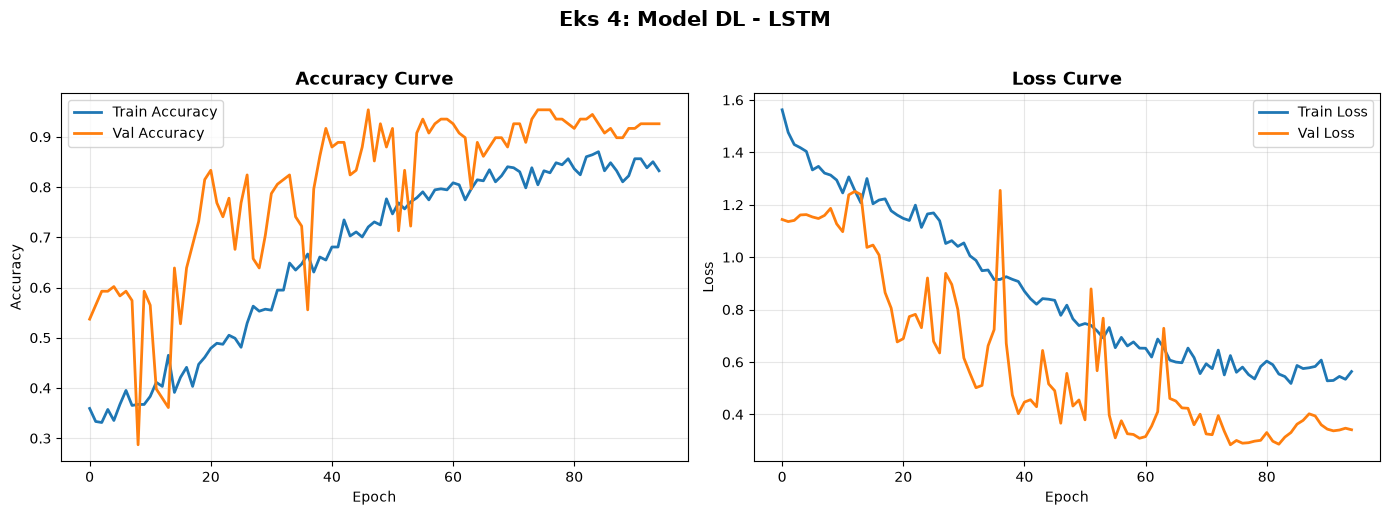

Model disimpan: ../Results\exp4_lstm_mfcc_20_model.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 640ms/step

--- Hasil Evaluasi: Eks 4: Model DL - LSTM ---
Accuracy  : 0.9259
Precision : 0.9288
Recall    : 0.9259
F1 Score  : 0.9265
ROC AUC   : 0.9929

Classification Report:
              precision    recall  f1-score   support

       lapar       0.88      0.95      0.91        38
      normal       0.98      0.93      0.95        56
      stress       0.86      0.86      0.86        14

    accuracy                           0.93       108
   macro avg       0.91      0.91      0.91       108
weighted avg       0.93      0.93      0.93       108



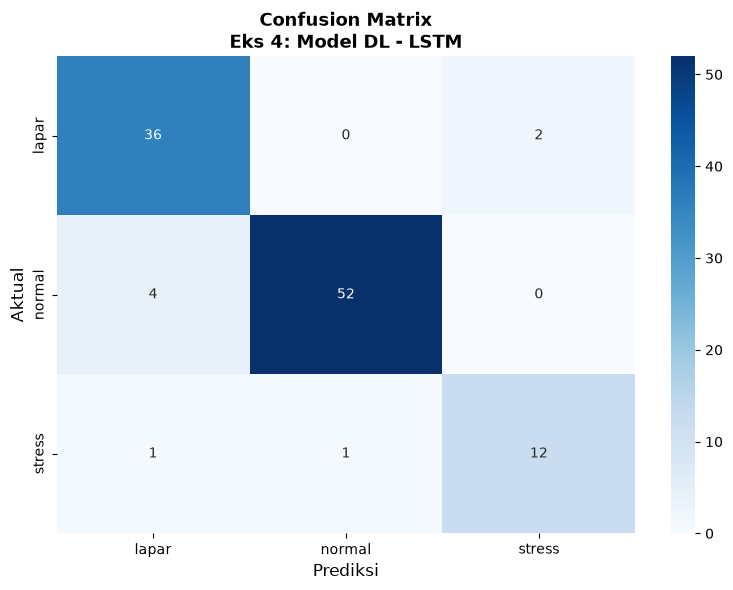

Waktu Eksekusi: 904.30 detik


In [70]:
# ═══ LSTM ═══
print('='*60); print('EKSPERIMEN 4 - LSTM'); print('='*60)
result_exp4_lstm = run_experiment(
    train_signals=exp2_train_signals, train_labels=exp2_train_labels,
    val_signals=list(val_signals), val_labels=list(val_labels),
    test_signals=list(test_signals), test_labels=list(test_labels),
    le=le, experiment_name='Eks 4: Model DL', variant_name='LSTM',
    model_builder='lstm', feature_method=BEST_FEATURE_METHOD,
    **BEST_FEATURE_KWARGS, save_prefix=f'exp4_lstm_{BEST_MFCC_NAME.lower().replace(" ", "_")}')

In [71]:
# ── Ringkasan Eksperimen 4
print('\n' + '='*60)
print('RINGKASAN EKSPERIMEN 4: PERBANDINGAN MODEL DEEP LEARNING')
print('='*60)

exp4_results = [result_exp4_dnn, result_exp4_cnn, result_exp4_lstm]
exp4_df = pd.DataFrame(exp4_results)
print(exp4_df.to_string(index=False))

best_exp4_idx = exp4_df['F1'].idxmax()
best_exp4 = exp4_df.iloc[best_exp4_idx]
print(f'\n✅ Model terbaik: {best_exp4["Variasi"]} (F1={best_exp4["F1"]:.4f})')


RINGKASAN EKSPERIMEN 4: PERBANDINGAN MODEL DEEP LEARNING
     Eksperimen Variasi  Accuracy  Precision  Recall     F1  ROC-AUC  Waktu (detik)
Eks 4: Model DL     DNN    0.9352     0.9419  0.9352 0.9356   0.9914          33.18
Eks 4: Model DL     CNN    0.9352     0.9423  0.9352 0.9358   0.9970          43.48
Eks 4: Model DL    LSTM    0.9259     0.9288  0.9259 0.9265   0.9929         904.30

✅ Model terbaik: CNN (F1=0.9358)


---
## 10. Ringkasan Seluruh Eksperimen

In [72]:
# ══════════════════════════════════════════════════════════════
# TABEL RINGKASAN SELURUH EKSPERIMEN
# ══════════════════════════════════════════════════════════════
print('='*70)
print('TABEL RINGKASAN SELURUH EKSPERIMEN')
print('='*70)

summary_df = pd.DataFrame(all_experiment_results)
print(summary_df.to_string(index=False))

summary_path = os.path.join(RESULTS_DIR, 'ringkasan_seluruh_eksperimen.csv')
summary_df.to_csv(summary_path, index=False)
print(f'\nTabel ringkasan disimpan: {summary_path}')

TABEL RINGKASAN SELURUH EKSPERIMEN
          Eksperimen             Variasi  Accuracy  Precision  Recall     F1  ROC-AUC  Waktu (detik)
    Eks 1: Imbalance   1. Raw (Tanpa CW)    0.9537     0.9553  0.9537 0.9534   0.9960          20.13
    Eks 1: Imbalance     2. Class Weight    0.9537     0.9548  0.9537 0.9538   0.9961          19.10
    Eks 1: Imbalance     3. Balance Aug.    0.9352     0.9361  0.9352 0.9355   0.9947          20.87
    Eks 1: Imbalance    4. Aug 500/kelas    0.9074     0.9087  0.9074 0.9077   0.9890          31.67
  Eks 2: MFCC Optim.             MFCC 13    0.9352     0.9350  0.9352 0.9341   0.9942          47.95
  Eks 2: MFCC Optim.             MFCC 20    0.9907     0.9910  0.9907 0.9908   0.9989          23.76
  Eks 2: MFCC Optim.     MFCC 40 Default    0.9537     0.9548  0.9537 0.9538   0.9961          16.08
  Eks 2: MFCC Optim.    MFCC 40 Improved    0.9444     0.9469  0.9444 0.9441   0.9946          18.44
Eks 3: Feature Extr.             MFCC 20    0.9907     0

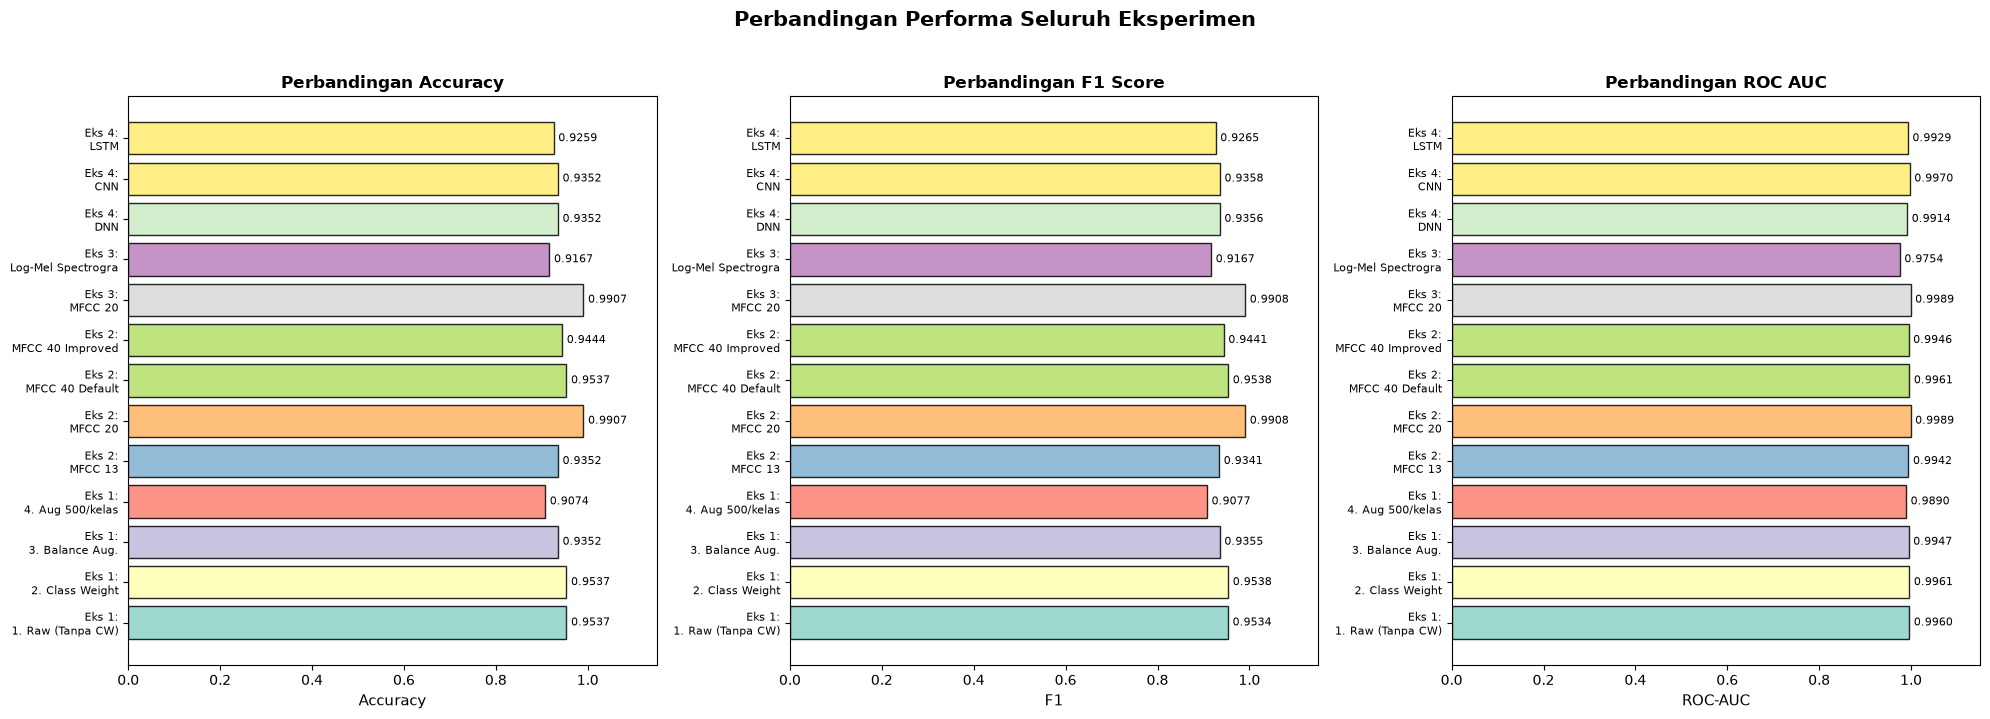

In [73]:
# ── Grafik Perbandingan Seluruh Eksperimen
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

summary_df['Label'] = summary_df.apply(
    lambda r: f"{r['Eksperimen'][:6]}\n{r['Variasi'][:18]}", axis=1)
colors = plt.cm.Set3(np.linspace(0, 1, len(summary_df)))

for ax, metric, title in zip(axes,
    ['Accuracy', 'F1', 'ROC-AUC'],
    ['Perbandingan Accuracy', 'Perbandingan F1 Score', 'Perbandingan ROC AUC']):
    ax.barh(range(len(summary_df)), summary_df[metric], color=colors, edgecolor='black', alpha=0.85)
    ax.set_yticks(range(len(summary_df)))
    ax.set_yticklabels(summary_df['Label'], fontsize=8)
    ax.set_xlabel(metric, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlim(0, 1.15)
    for i, v in enumerate(summary_df[metric]):
        ax.text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=8)

plt.suptitle('Perbandingan Performa Seluruh Eksperimen', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'perbandingan_seluruh_eksperimen.png'),
            dpi=150, bbox_inches='tight')
plt.show()

---
## 11. Kesimpulan
Konfigurasi terbaik yang direkomendasikan berdasarkan seluruh eksperimen dapat dilihat pada tabel ringkasan di atas. Model dengan skor F1 tertinggi menunjukkan keseimbangan terbaik antara precision dan recall.

In [ ]:
print('\n' + '='*60)
print('KONFIGURASI TERBAIK')
print('='*60)
print(f'Augmentasi    : {BEST_AUG_STRATEGY} (target={best_aug_target})')
print(f'Feature       : {BEST_FEATURE_NAME} ({BEST_FEATURE_METHOD})')
print(f'Model         : {best_exp4["Variasi"]}')
print(f'F1 Score      : {best_exp4["F1"]:.4f}')


KONFIGURASI TERBAIK
Augmentasi    : none (target=None)
Feature       : MFCC 20 (mfcc)
Model         : CNN
F1 Score      : 0.9358

✅ Seluruh eksperimen selesai!
✅ Semua hasil tersimpan di: c:\S2-Ilmu Komputer 24\Project\Kambing\Results
